### **Importing Dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import scipy.stats as st  # ✅ stats lives here

from typing import Optional, Tuple, Dict

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from lifelines.plotting import add_at_risk_counts

from sklearn.model_selection import KFold, train_test_split
from lifelines.statistics import logrank_test

from matplotlib.ticker import FuncFormatter
from scipy.stats import gaussian_kde, norm  # optional; enable if you use them


# !pip install numpy pandas matplotlib lifelines scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib

from going_modular import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 


from rpy2.robjects import Formula
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects import r
from rpy2.robjects import pandas2ri, conversion
from rpy2.robjects.packages import importr
from rpy2.robjects.vectors import DataFrame, FloatVector, IntVector, ListVector, Vector, StrVector

rstpm2 = importr("rstpm2")
survival = importr("survival")
ggplot2 = importr("ggplot2")
graphics = importr("graphics")
stats = importr("stats")
lmtest = importr("lmtest")


### **Importing Datasets**

In [2]:
comb_dat = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/combined_other_datasets_for_modeling.csv')
comb_dat.columns

Index(['subject_id', 'Event', 'Vital_capacity', 'Sex', 'Onset_site',
       'Study_Arm', 'European', 'Age', 'Diagnostic_Delay', 'Disease_Duration',
       'TRICALS', 'Study_id', 'Expt'],
      dtype='object')

In [3]:
print(f"{comb_dat.Expt.value_counts().to_dict()}\n")
print(f"{comb_dat.Study_id.value_counts().to_dict()}\n")
print(f"{comb_dat.Sex.value_counts().to_dict()}\n")
print(f"{comb_dat.Onset_site.value_counts().to_dict()}\n")
print(f"{comb_dat.Study_Arm.value_counts().to_dict()}\n")
print(f"{comb_dat.European.value_counts().to_dict()}\n")


{'riluzole': 1282, 'mirocals': 220, 'licals': 176}

{'301': 959, 'miro': 220, 'lica': 176, '302': 168, '216': 155}

{'1': 748, '0': 534, 'M': 136, 'Male': 126, 'F': 84, 'Female': 50}

{'1.0': 1151, 'Limb': 318, '0.0': 82, 'Bulbar': 77, '2.0': 49, 'Other': 1}

{'ACTIVE': 876, 'PLACEBO': 406, 'Placebo': 197, 'IL2': 110, 'Active': 89}

{1: 1649, 2: 9, 3: 8, 4: 7, 0: 4, 5: 1}



In [4]:
comb_dat['Sex'] = comb_dat['Sex'].map({'1': 'Male', '0': 'Female', 'M': 'Male', 'Male': "Male", 'F': 'Female', 'Female': 'Female'})
comb_dat['Onset_site'] = comb_dat['Onset_site'].map({'1.0': 'Limb', 'Limb': 'Limb', '0.0': 'Bulbar', 'Bulbar': 'Bulbar', '2.0': 'Limb', 'Other': 'Other'})
comb_dat['Study_Arm'] = comb_dat['Study_Arm'].map({'ACTIVE': 'Active', 'PLACEBO': 'Placebo', 'Placebo': 'Placebo', 'IL2': 'Active', 'Active': 'Active'})

In [5]:
print(f"{comb_dat.Expt.value_counts().to_dict()}\n")
print(f"{comb_dat.Study_id.value_counts().to_dict()}\n")
print(f"{comb_dat.Sex.value_counts().to_dict()}\n")
print(f"{comb_dat.Onset_site.value_counts().to_dict()}\n")
print(f"{comb_dat.Study_Arm.value_counts().to_dict()}\n")
print(f"{comb_dat.European.value_counts().to_dict()}\n")

{'riluzole': 1282, 'mirocals': 220, 'licals': 176}

{'301': 959, 'miro': 220, 'lica': 176, '302': 168, '216': 155}

{'Male': 1010, 'Female': 668}

{'Limb': 1518, 'Bulbar': 159, 'Other': 1}

{'Active': 1075, 'Placebo': 603}

{1: 1649, 2: 9, 3: 8, 4: 7, 0: 4, 5: 1}



In [6]:
comb_dat = comb_dat[comb_dat["Onset_site"] != 'Other']
comb_dat = comb_dat[comb_dat["European"] == 1]


In [7]:
miro = comb_dat[comb_dat["Expt"] == 'mirocals']
lica = comb_dat[comb_dat["Expt"] == 'licals']
ril_301 = comb_dat[comb_dat["Study_id"] == '301']

miro = miro[['subject_id', 'Event',	'Vital_capacity', 'Sex', 'Onset_site', 'Study_Arm',	'Age', 'Diagnostic_Delay', 'Disease_Duration', 'TRICALS']]
lica = lica[['subject_id', 'Event', 'Vital_capacity', 'Sex', 'Onset_site', 'Study_Arm', 'Age', 'Diagnostic_Delay', 'Disease_Duration', 'TRICALS']]
ril_301 = ril_301[['subject_id', 'Event', 'Vital_capacity', 'Sex', 'Onset_site', 'Study_Arm', 'Age', 'Diagnostic_Delay', 'Disease_Duration', 'TRICALS']]


print(f"miro: {miro.shape} | lica: {lica.shape} | rilu: {ril_301.shape}")
miro.head(2)

miro: (219, 10) | lica: (172, 10) | rilu: (938, 10)


,subject_id,Event,Vital_capacity,Sex,Onset_site,Study_Arm,Age,Diagnostic_Delay,Disease_Duration,TRICALS
176,1-62478,1.0,99.0,Female,Limb,Placebo,70.927,15.108,29.174444,-4.550056
177,1-62479,1.0,81.0,Female,Bulbar,Active,65.391,15.600,24.144657,-2.933660


In [8]:
proact_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_miro_full.csv')
proact_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_lica_full.csv')

proact_miro['Onset_site'] = proact_miro['Onset_site'].map({'limb': "Limb", 'bulbar': "Bulbar"})
proact_lica['Onset_site'] = proact_lica['Onset_site'].map({'limb': "Limb", 'bulbar': "Bulbar"})

proact_miro = proact_miro[['subject_id', 'Event',	'Vital_capacity', 'Sex', 'Onset_site', 'Study_Arm',	'Age', 'Diagnostic_Delay', 'Disease_Duration', 'TRICALS']]
proact_lica = proact_lica[['subject_id', 'Event', 'Vital_capacity', 'Sex', 'Onset_site', 'Study_Arm', 'Age', 'Diagnostic_Delay', 'Disease_Duration', 'TRICALS']]

proact_miro['Sex_Male'] = (proact_miro['Sex'] == 'Male').astype(int)
proact_lica['Sex_Male'] = (proact_lica['Sex'] == 'Male').astype(int)

proact_miro['Onset_Limb'] = (proact_miro['Onset_site'] == 'Limb').astype(int)
proact_lica['Onset_Limb'] = (proact_lica['Onset_site'] == 'Limb').astype(int)

print(f"proact_miro: {proact_miro.shape} | proact_lica: {proact_lica.shape}")
proact_lica.head(2)

proact_miro: (428, 12) | proact_lica: (627, 12)


,subject_id,Event,Vital_capacity,Sex,Onset_site,Study_Arm,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_Male,Onset_Limb
0,1333,1,70.489883,Female,Limb,Active,55.0,11.906702,22.996058,-3.779545,0,1
1,3350,0,99.427009,Male,Limb,Active,70.3,11.019711,21.747700,-4.907534,1,1


In [9]:
proact_lica.Sex_Male.value_counts()

Sex_Male
1    395
0    232
Name: count, dtype: int64

In [10]:

MND_lica_full = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_licals_full.csv')
MND_miro_full = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_mirocals_full.csv')
MND_rilu_full = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_riluzole_full.csv')

In [11]:
# MND_miro_full.columns

In [12]:
MND_miro_full = MND_miro_full[['subject_id', 'Event', 'Disease_Duration', 'AgeOfOnset', 'Diagnostic_Delay1', 'Sex_Male',
                                 'Onset_Limb', 'TRICALS_Risk_Score']]
MND_lica_full = MND_lica_full[['subject_id', 'Event', 'Disease_Duration', 'AgeOfOnset', 'Diagnostic_Delay1', 'Sex_Male',
                                 'Onset_Limb', 'TRICALS_Risk_Score']]
MND_rilu_full = MND_rilu_full[['subject_id', 'Event', 'Disease_Duration', 'AgeOfOnset', 'Diagnostic_Delay1', 'Sex_Male',
                                 'Onset_Limb', 'TRICALS_Risk_Score']]

print(f"MND_miro: {MND_miro_full.shape} | MND_lica: {MND_lica_full.shape} | MND_rilu: {MND_rilu_full.shape}")

MND_miro: (92, 8) | MND_lica: (146, 8) | MND_rilu: (169, 8)


In [13]:
MND_miro_full.head(2)

,subject_id,Event,Disease_Duration,AgeOfOnset,Diagnostic_Delay1,Sex_Male,Onset_Limb,TRICALS_Risk_Score
0,257,1,7.785808,48.41,3.318003,1,0,-2.531038
1,1086,1,21.222076,64.43,3.646518,0,0,-2.607816


In [14]:
miro.head(2)

,subject_id,Event,Vital_capacity,Sex,Onset_site,Study_Arm,Age,Diagnostic_Delay,Disease_Duration,TRICALS
176,1-62478,1.0,99.0,Female,Limb,Placebo,70.927,15.108,29.174444,-4.550056
177,1-62479,1.0,81.0,Female,Bulbar,Active,65.391,15.600,24.144657,-2.933660


In [15]:
# MND_lica_full.columns

In [16]:
print(MND_miro_full.Sex_Male.value_counts().to_dict())
print(MND_miro_full.Onset_Limb.value_counts().to_dict())

{1: 56, 0: 36}
{1: 64, 0: 28}


In [17]:
MND_lica_full['Sex_Male'] = MND_lica_full['Sex_Male'].map({1: "Male", 0: "Female"})
MND_lica_full['Onset_Limb'] = MND_lica_full['Onset_Limb'].map({1: "Limb", 0: "Bulbar"})

MND_miro_full['Sex_Male'] = MND_miro_full['Sex_Male'].map({1: "Male", 0: "Female"})
MND_miro_full['Onset_Limb'] = MND_miro_full['Onset_Limb'].map({1: "Limb", 0: "Bulbar"})

MND_rilu_full['Sex_Male'] = MND_rilu_full['Sex_Male'].map({1: "Male", 0: "Female"})
MND_rilu_full['Onset_Limb'] = MND_rilu_full['Onset_Limb'].map({1: "Limb", 0: "Bulbar"})

In [18]:
MND_lica_full = MND_lica_full.rename(columns={'AgeOfOnset': 'Age', 'Diagnostic_Delay1': 'Diagnostic_Delay', 'Sex_Male': 'Sex', 'Onset_Limb': 'Onset_site', 'TRICALS_Risk_Score': 'TRICALS'})
MND_miro_full = MND_miro_full.rename(columns={'AgeOfOnset': 'Age', 'Diagnostic_Delay1': 'Diagnostic_Delay', 'Sex_Male': 'Sex', 'Onset_Limb': 'Onset_site', 'TRICALS_Risk_Score': 'TRICALS'})
MND_rilu_full = MND_rilu_full.rename(columns={'AgeOfOnset': 'Age', 'Diagnostic_Delay1': 'Diagnostic_Delay', 'Sex_Male': 'Sex', 'Onset_Limb': 'Onset_site', 'TRICALS_Risk_Score': 'TRICALS'})


In [19]:
MND_lica_full.head(3)

,subject_id,Event,Disease_Duration,Age,Diagnostic_Delay,Sex,Onset_site,TRICALS
0,32,0,35.939553,65.760002,22.010512,Male,Limb,-5.485294
1,257,1,7.785808,48.410000,3.318003,Male,Bulbar,-2.531038
2,1086,1,21.222076,64.430000,3.646518,Female,Bulbar,-2.607816


In [20]:
miro.head(3)

,subject_id,Event,Vital_capacity,Sex,Onset_site,Study_Arm,Age,Diagnostic_Delay,Disease_Duration,TRICALS
176,1-62478,1.0,99.0,Female,Limb,Placebo,70.927,15.108,29.174444,-4.550056
177,1-62479,1.0,81.0,Female,Bulbar,Active,65.391,15.600,24.144657,-2.933660
178,1-62480,0.0,96.0,Male,Limb,Active,57.024,8.904,31.308967,-5.212384


### **Comparing Baseline Characteristics of Two datasets**

In [21]:
def compare_numeric(df1, df2, variables, name1='Dataset1', name2='Dataset2'):
    rows = []
    for var in variables:
        mean1, sd1 = df1[var].mean(), df1[var].std()
        mean2, sd2 = df2[var].mean(), df2[var].std()

        # Two-sample t-test
        tstat, pval = st.ttest_ind(df1[var].dropna(),
                                    df2[var].dropna(),
                                    equal_var=False)

        rows.append({
            "Variable": var,
            f"{name1} (Mean ± SD)": f"{mean1:.2f} ± {sd1:.2f}",
            f"{name2} (Mean ± SD)": f"{mean2:.2f} ± {sd2:.2f}",
            "p-value": round(pval, 4)
        })
    return  pd.DataFrame(rows)

def compare_categorical(df1, df2, variables, name1='Dataset1', name2='Dataset2'):
    rows = []
    for var in variables:
        tab1 = df1[var].value_counts()
        tab2 = df2[var].value_counts()

        combined = pd.concat([tab1, tab2], axis=1, keys=[name1, name2]).fillna(0)

        # Chi-square test
        chi2, pval, _, _ = st.chi2_contingency(combined.T)

        for level in combined.index:
            rows.append({
                "Variable": f"{var} = {level}",
                f"{name1} (n, %)": f"{int(combined.loc[level, name1])} "
                                    f"({combined.loc[level, name1]/len(df1)*100:.1f}%)",
                f"{name2} (n, %)": f"{int(combined.loc[level, name2])} "
                                    f"({combined.loc[level, name2]/len(df2)*100:.1f}%)",
                "p-value": round(pval, 4) 
            })

    return pd.DataFrame(rows)

def compare_datasets_table(
    df1, df2,
    numeric_vars,
    categorical_vars,
    name1="Dataset1",
    name2="Dataset2"
):
    rows = []

    # ==========================
    # Continuous Variables
    # ==========================
    for var in numeric_vars:
        x1 = df1[var].dropna()
        x2 = df2[var].dropna()

        tstat, pval = st.ttest_ind(x1, x2, equal_var=False)

        rows.append({
            "Variable": var,
            "Type": "Continuous",
            f"{name1}": f"{x1.mean():.2f} ± {x1.std():.2f}",
            f"{name2}": f"{x2.mean():.2f} ± {x2.std():.2f}",
            "p-value": round(pval, 4)
        })

    # ==========================
    # Categorical Variables
    # ==========================
    for var in categorical_vars:

        tab1 = df1[var].value_counts(dropna=False)
        tab2 = df2[var].value_counts(dropna=False)

        combined = pd.concat(
            [tab1, tab2],
            axis=1,
            keys=[name1, name2]
        ).fillna(0)

        # Chi-square test
        chi2, pval, _, _ = st.chi2_contingency(combined.T)

        # Header row (variable-level p-value)
        rows.append({
            "Variable": var,
            "Type": "Categorical",
            f"{name1}": "",
            f"{name2}": "",
            "p-value": round(pval, 4)
        })

        # Stable ordering (alphabetical; can customise)
        levels = sorted(combined.index, key=lambda x: str(x))

        for level in levels:
            n1 = combined.loc[level, name1]
            n2 = combined.loc[level, name2]

            rows.append({
                "Variable": f"   - {level}",
                "Type": "Categorical",
                f"{name1}": f"{int(n1)} ({n1/len(df1)*100:.1f}%)",
                f"{name2}": f"{int(n2)} ({n2/len(df2)*100:.1f}%)",
                "p-value": ""
            })

    return pd.DataFrame(rows)



In [22]:
miro.head(2)

,subject_id,Event,Vital_capacity,Sex,Onset_site,Study_Arm,Age,Diagnostic_Delay,Disease_Duration,TRICALS
176,1-62478,1.0,99.0,Female,Limb,Placebo,70.927,15.108,29.174444,-4.550056
177,1-62479,1.0,81.0,Female,Bulbar,Active,65.391,15.600,24.144657,-2.933660


In [23]:
# miro1 lica1 rilu1 pro1 
# miro2 lica2 rilu2 pro2 
# MND_lica1 MND_miro1 MND_rilu1 

num_vars = ["Age", "Diagnostic_Delay", "Vital_capacity"]
cat_vars = ["Sex", "Onset_site"]

In [24]:
ml = compare_datasets_table(miro, lica, num_vars, cat_vars, name1="MIROCALS",name2="LICALS")
ml.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_LICALS_Table1.xlsx", index=False)
ml

,Variable,Type,MIROCALS,LICALS,p-value
0,Age,Continuous,58.35 ± 10.28,58.66 ± 10.80,0.7739
1,Diagnostic_Delay,Continuous,9.71 ± 4.94,16.32 ± 4.96,0.0
2,Vital_capacity,Continuous,95.64 ± 16.21,91.30 ± 17.79,0.0132
3,Sex,Categorical,,,0.0698
4,- Female,Categorical,84 (38.4%),50 (29.1%),
5,- Male,Categorical,135 (61.6%),122 (70.9%),
6,Onset_site,Categorical,,,0.7252
7,- Bulbar,Categorical,45 (20.5%),32 (18.6%),
8,- Limb,Categorical,174 (79.5%),140 (81.4%),


In [25]:
mr = compare_datasets_table(miro, ril_301, num_vars, cat_vars, name1="MIROCALS",name2="RILUZOLE")
mr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_RILUZOLE_Table1.xlsx", index=False)
mr

,Variable,Type,MIROCALS,RILUZOLE,p-value
0,Age,Continuous,58.35 ± 10.28,56.75 ± 10.99,0.0416
1,Diagnostic_Delay,Continuous,9.71 ± 4.94,0.12 ± 0.25,0.0
2,Vital_capacity,Continuous,95.64 ± 16.21,88.43 ± 18.80,0.0
3,Sex,Categorical,,,0.6935
4,- Female,Categorical,84 (38.4%),376 (40.1%),
5,- Male,Categorical,135 (61.6%),562 (59.9%),
6,Onset_site,Categorical,,,0.0
7,- Bulbar,Categorical,45 (20.5%),0 (0.0%),
8,- Limb,Categorical,174 (79.5%),938 (100.0%),


You need to confirm the diagnostic delay for riluzole. Its not looking real. CHeck the original data or the original paper

In [26]:
lr = compare_datasets_table(lica, ril_301, num_vars, cat_vars, name1="LICALS",name2="RILUZOLE")
lr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/LICALS_vs_RILUZOLE_Table1.xlsx", index=False)
lr

,Variable,Type,LICALS,RILUZOLE,p-value
0,Age,Continuous,58.66 ± 10.80,56.75 ± 10.99,0.0345
1,Diagnostic_Delay,Continuous,16.32 ± 4.96,0.12 ± 0.25,0.0
2,Vital_capacity,Continuous,91.30 ± 17.79,88.43 ± 18.80,0.0546
3,Sex,Categorical,,,0.0082
4,- Female,Categorical,50 (29.1%),376 (40.1%),
5,- Male,Categorical,122 (70.9%),562 (59.9%),
6,Onset_site,Categorical,,,0.0
7,- Bulbar,Categorical,32 (18.6%),0 (0.0%),
8,- Limb,Categorical,140 (81.4%),938 (100.0%),


In [27]:
num_vars = ["Age", "Diagnostic_Delay"]#, "Vital_capacity"]
cat_vars = ["Sex", "Onset_site"]

In [28]:
mndm_mndl = compare_datasets_table(MND_miro_full, MND_lica_full, num_vars, cat_vars, name1="MIROCALS MND",name2="LICALS MND")
mndm_mndl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MND_MIROCALS_vs_MND_LICALS.xlsx", index=False)
mndm_mndl

,Variable,Type,MIROCALS MND,LICALS MND,p-value
0,Age,Continuous,57.35 ± 12.54,57.10 ± 12.34,0.8766
1,Diagnostic_Delay,Continuous,7.14 ± 3.84,9.30 ± 5.35,0.0004
2,Sex,Categorical,,,0.7629
3,- Female,Categorical,36 (39.1%),53 (36.3%),
4,- Male,Categorical,56 (60.9%),93 (63.7%),
5,Onset_site,Categorical,,,0.8974
6,- Bulbar,Categorical,28 (30.4%),42 (28.8%),
7,- Limb,Categorical,64 (69.6%),104 (71.2%),


In [29]:
mndm_mndr = compare_datasets_table(MND_miro_full, MND_rilu_full, num_vars, cat_vars, name1="MIROCALS MND",name2="RILUZOLE MND")
mndm_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MND_MIROCALS_vs_MND_RILUZOLE.xlsx", index=False)
mndm_mndr

,Variable,Type,MIROCALS MND,RILUZOLE MND,p-value
0,Age,Continuous,57.35 ± 12.54,57.90 ± 9.81,0.7191
1,Diagnostic_Delay,Continuous,7.14 ± 3.84,11.81 ± 7.13,0.0
2,Sex,Categorical,,,0.872
3,- Female,Categorical,36 (39.1%),63 (37.3%),
4,- Male,Categorical,56 (60.9%),106 (62.7%),
5,Onset_site,Categorical,,,0.9884
6,- Bulbar,Categorical,28 (30.4%),53 (31.4%),
7,- Limb,Categorical,64 (69.6%),116 (68.6%),


In [30]:
mndl_mndr = compare_datasets_table(MND_lica_full, MND_rilu_full, num_vars, cat_vars, name1="LICALS MND",name2="RILUZOLE MND")
mndl_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MND_LICALS_vs_MND_RILUZOLE.xlsx", index=False)
mndl_mndr

,Variable,Type,LICALS MND,RILUZOLE MND,p-value
0,Age,Continuous,57.10 ± 12.34,57.90 ± 9.81,0.5281
1,Diagnostic_Delay,Continuous,9.30 ± 5.35,11.81 ± 7.13,0.0004
2,Sex,Categorical,,,0.9505
3,- Female,Categorical,53 (36.3%),63 (37.3%),
4,- Male,Categorical,93 (63.7%),106 (62.7%),
5,Onset_site,Categorical,,,0.7061
6,- Bulbar,Categorical,42 (28.8%),53 (31.4%),
7,- Limb,Categorical,104 (71.2%),116 (68.6%),


In [31]:
# m_mndr = compare_datasets_table(miro1, MND_miro_full1, num_vars, cat_vars, name1="MIROCALS",name2="MND MIROCALS")
# m_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_MND_MIROCALS.xlsx", index=False)
# m_mndr

In [32]:
# l_mndl = compare_datasets_table(lica1, MND_lica_full1, num_vars, cat_vars, name1="LICALS",name2="MND LICALS")
# l_mndl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/LICALS_vs_MND_LICALS.xlsx", index=False)
# l_mndl

In [33]:
# r_mndr = compare_datasets_table(rilu1, MND_rilu_full1, num_vars, cat_vars, name1="RILUZOLE",name2="MND RILUZOLE")
# r_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/RILUZOLE_vs_MND_RILUZOLE.xlsx", index=False)
# r_mndr

### **Comparing clinical trial placebo and population registry dataset**

In [34]:
miro_pla = miro[miro['Study_Arm'] == 'Placebo']
lica_pla = lica[lica['Study_Arm'] == 'Placebo']
ril_301_pla = ril_301[ril_301['Study_Arm'] == 'Placebo']

print(f"miro: {miro.shape} | lica: {lica.shape} | ril_301: {ril_301.shape}\n")
print(f"miro_pla: {miro_pla.shape} | lica_pla: {lica_pla.shape} | ril_301_pla: {ril_301_pla.shape}")

miro: (219, 10) | lica: (172, 10) | ril_301: (938, 10)

miro_pla: (109, 10) | lica_pla: (84, 10) | ril_301_pla: (238, 10)


In [35]:
# proact_miro.Study_Arm.value_counts()

In [36]:
proact_miro_pla = proact_miro[proact_miro['Study_Arm'] == 'Placebo']
proact_lica_pla = proact_lica[proact_lica['Study_Arm'] == 'Placebo']

print(f"proact_miro_pla: {proact_miro_pla.shape} | proact_lica_pla: {proact_lica_pla.shape}\n")

proact_miro_pla: (188, 12) | proact_lica_pla: (281, 12)



In [37]:
print(ril_301_pla.shape)
ril_301_pla.head(1)

(238, 10)


,subject_id,Event,Vital_capacity,Sex,Onset_site,Study_Arm,Age,Diagnostic_Delay,Disease_Duration,TRICALS
552,11002,0.0,127.558757,Male,Limb,Placebo,42.0,0.0,19.152431,-3.891616


#### **Select only the placebo arm**

In [38]:
m_mndr = compare_datasets_table(miro_pla, lica_pla, num_vars, cat_vars, name1="MIROCALS PLACEBO",name2="LICALS PLACEBO")
m_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_MND_MIROCALS.xlsx", index=False)
m_mndr

,Variable,Type,MIROCALS PLACEBO,LICALS PLACEBO,p-value
0,Age,Continuous,58.64 ± 10.53,58.74 ± 10.10,0.9442
1,Diagnostic_Delay,Continuous,10.09 ± 5.14,16.57 ± 4.47,0.0
2,Sex,Categorical,,,0.3704
3,- Female,Categorical,43 (39.4%),27 (32.1%),
4,- Male,Categorical,66 (60.6%),57 (67.9%),
5,Onset_site,Categorical,,,0.7045
6,- Bulbar,Categorical,23 (21.1%),15 (17.9%),
7,- Limb,Categorical,86 (78.9%),69 (82.1%),


In [39]:
m_mndr = compare_datasets_table(miro_pla, ril_301_pla, num_vars, cat_vars, name1="MIROCALS PLACEBO",name2="RILUZOLE PLACEBO")
m_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_MND_MIROCALS.xlsx", index=False)
m_mndr

,Variable,Type,MIROCALS PLACEBO,RILUZOLE PLACEBO,p-value
0,Age,Continuous,58.64 ± 10.53,56.00 ± 11.55,0.0373
1,Diagnostic_Delay,Continuous,10.09 ± 5.14,0.11 ± 0.23,0.0
2,Sex,Categorical,,,0.8051
3,- Female,Categorical,43 (39.4%),89 (37.4%),
4,- Male,Categorical,66 (60.6%),149 (62.6%),
5,Onset_site,Categorical,,,0.0
6,- Bulbar,Categorical,23 (21.1%),0 (0.0%),
7,- Limb,Categorical,86 (78.9%),238 (100.0%),


In [40]:
m_mndr = compare_datasets_table(lica_pla, ril_301_pla, num_vars, cat_vars, name1="LICALS PLACEBO",name2="RILUZOLE PLACEBO")
m_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_MND_MIROCALS.xlsx", index=False)
m_mndr

,Variable,Type,LICALS PLACEBO,RILUZOLE PLACEBO,p-value
0,Age,Continuous,58.74 ± 10.10,56.00 ± 11.55,0.0415
1,Diagnostic_Delay,Continuous,16.57 ± 4.47,0.11 ± 0.23,0.0
2,Sex,Categorical,,,0.4655
3,- Female,Categorical,27 (32.1%),89 (37.4%),
4,- Male,Categorical,57 (67.9%),149 (62.6%),
5,Onset_site,Categorical,,,0.0
6,- Bulbar,Categorical,15 (17.9%),0 (0.0%),
7,- Limb,Categorical,69 (82.1%),238 (100.0%),


In [41]:
m_mndr = compare_datasets_table(miro_pla, MND_miro_full, num_vars, cat_vars, name1="MIROCALS PLACEBO",name2="MIROCALS MND")
m_mndr.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_vs_MND_MIROCALS.xlsx", index=False)
m_mndr

,Variable,Type,MIROCALS PLACEBO,MIROCALS MND,p-value
0,Age,Continuous,58.64 ± 10.53,57.35 ± 12.54,0.4388
1,Diagnostic_Delay,Continuous,10.09 ± 5.14,7.14 ± 3.84,0.0
2,Sex,Categorical,,,1.0
3,- Female,Categorical,43 (39.4%),36 (39.1%),
4,- Male,Categorical,66 (60.6%),56 (60.9%),
5,Onset_site,Categorical,,,0.1762
6,- Bulbar,Categorical,23 (21.1%),28 (30.4%),
7,- Limb,Categorical,86 (78.9%),64 (69.6%),


In [42]:
l_mndl = compare_datasets_table(lica_pla, MND_lica_full, num_vars, cat_vars, name1="LICALS PLACEBO",name2="LICALS MND")
l_mndl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/LICALS_vs_MND_LICALS.xlsx", index=False)
l_mndl

,Variable,Type,LICALS PLACEBO,LICALS MND,p-value
0,Age,Continuous,58.74 ± 10.10,57.10 ± 12.34,0.275
1,Diagnostic_Delay,Continuous,16.57 ± 4.47,9.30 ± 5.35,0.0
2,Sex,Categorical,,,0.6214
3,- Female,Categorical,27 (32.1%),53 (36.3%),
4,- Male,Categorical,57 (67.9%),93 (63.7%),
5,Onset_site,Categorical,,,0.0917
6,- Bulbar,Categorical,15 (17.9%),42 (28.8%),
7,- Limb,Categorical,69 (82.1%),104 (71.2%),


In [43]:
l_mndl = compare_datasets_table(ril_301_pla, MND_rilu_full, num_vars, cat_vars, name1="RILUZOLE PLACEBO",name2="RILUZOLE MND")
l_mndl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/RILUZOLE_vs_MND_RILUZOLE.xlsx", index=False)
l_mndl

,Variable,Type,RILUZOLE PLACEBO,RILUZOLE MND,p-value
0,Age,Continuous,56.00 ± 11.55,57.90 ± 9.81,0.0756
1,Diagnostic_Delay,Continuous,0.11 ± 0.23,11.81 ± 7.13,0.0
2,Sex,Categorical,,,1.0
3,- Female,Categorical,89 (37.4%),63 (37.3%),
4,- Male,Categorical,149 (62.6%),106 (62.7%),
5,Onset_site,Categorical,,,0.0
6,- Bulbar,Categorical,0 (0.0%),53 (31.4%),
7,- Limb,Categorical,238 (100.0%),116 (68.6%),


In [44]:
l_mndl = compare_datasets_table(proact_miro_pla, MND_miro_full, num_vars, cat_vars, name1="MIROCALS PROACT PLACEBO",name2="MIROCALS MND")
l_mndl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/MIROCALS_PROACT_vs_MND_MIROCALS.xlsx", index=False)
l_mndl

,Variable,Type,MIROCALS PROACT PLACEBO,MIROCALS MND,p-value
0,Age,Continuous,59.05 ± 8.23,57.35 ± 12.54,0.2414
1,Diagnostic_Delay,Continuous,8.21 ± 3.92,7.14 ± 3.84,0.0307
2,Sex,Categorical,,,0.7265
3,- Female,Categorical,68 (36.2%),36 (39.1%),
4,- Male,Categorical,120 (63.8%),56 (60.9%),
5,Onset_site,Categorical,,,0.0215
6,- Bulbar,Categorical,33 (17.6%),28 (30.4%),
7,- Limb,Categorical,155 (82.4%),64 (69.6%),


In [45]:
# proact_lica_pla.Onset_site.value_counts()

In [46]:
l_mndl = compare_datasets_table(proact_lica_pla, MND_lica_full, num_vars, cat_vars, name1="LICALS PROACT PLACEBO",name2="LICALS MND")
l_mndl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/LICALS_PROACT_vs_MND_LICALS.xlsx", index=False)
l_mndl

,Variable,Type,LICALS PROACT PLACEBO,LICALS MND,p-value
0,Age,Continuous,59.56 ± 9.01,57.10 ± 12.34,0.0339
1,Diagnostic_Delay,Continuous,9.45 ± 5.09,9.30 ± 5.35,0.7803
2,Sex,Categorical,,,0.9119
3,- Female,Categorical,105 (37.4%),53 (36.3%),
4,- Male,Categorical,176 (62.6%),93 (63.7%),
5,Onset_site,Categorical,,,0.158
6,- Bulbar,Categorical,62 (22.1%),42 (28.8%),
7,- Limb,Categorical,219 (77.9%),104 (71.2%),


Check that for the summary statistcs data the continuous covariates are not scale to have mean=0 and variance=1

In [47]:
# print(f"{proact0_pla.Study_Arm_Placebo.value_counts()}\n")
# print(f"{proact0_pla.Event.value_counts()}")

### **Plotting K-M curves**

In [48]:
def km_curve_fit(df: pd.DataFrame, label: str):
    km = KaplanMeierFitter()
    km.fit(durations=df["Disease_Duration"], event_observed=(df["Event"] == 1), label=label)
    return km

def plot_km_placebo_vs_population(placebo_df: pd.DataFrame, population_df: pd.DataFrame, x_max= None, title: str = "Trial name"):
    km_c = km_curve_fit(placebo_df, "Clinical trial placebo")
    km_p = km_curve_fit(population_df, "Population registry")

    ax = km_c.plot_survival_function(ci_show=True)
    km_p.plot_survival_function(ci_show=True, ax=ax)

    if x_max is None:
        x_max = float(pd.concat([placebo_df['Disease_Duration'], population_df['Disease_Duration']]).dropna().max())

    ax.set_xlim(-0.05, x_max + 1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Disease duration (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.grid(True, alpha=0.5)

    add_at_risk_counts(km_c, km_p, ax=ax)
    # add_at_risk_counts(km_p, ax=ax)

    # fig.subplots_adjust(bottom=0.25)

    plt.show()

In [52]:
MND_miro_full.head(2)

,subject_id,Event,Disease_Duration,Age,Diagnostic_Delay,Sex,Onset_site,TRICALS
0,257,1,7.785808,48.41,3.318003,Male,Bulbar,-2.531038
1,1086,1,21.222076,64.43,3.646518,Female,Bulbar,-2.607816


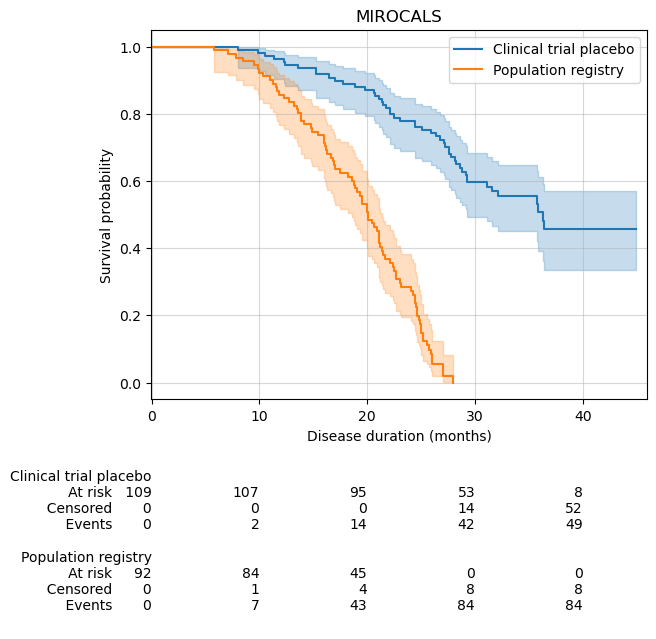

In [49]:
plot_km_placebo_vs_population(miro_pla, MND_miro_full, title = "MIROCALS")

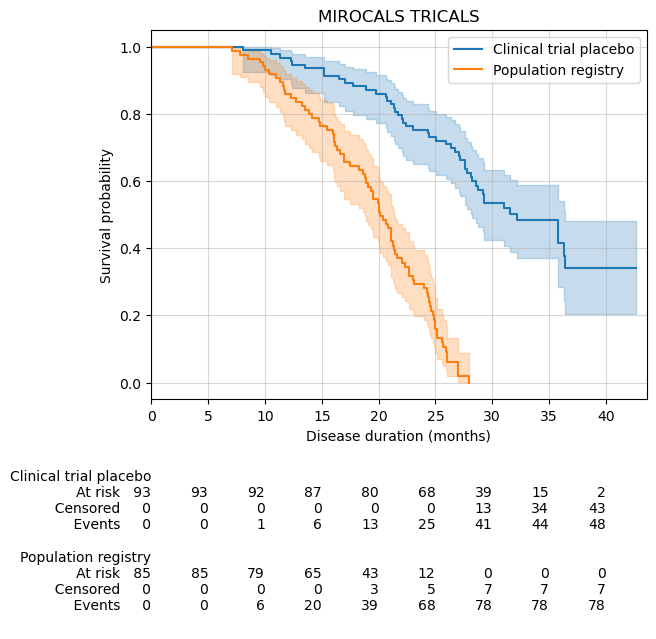

In [57]:
miro_pla_trical = miro_pla[(miro_pla['TRICALS'] >= -6) & (miro_pla['TRICALS'] <= -2)]
MND_miro_full_trical = MND_miro_full[(MND_miro_full['TRICALS'] >= -6) & (MND_miro_full['TRICALS'] <= -2)]
miro_pla_trical.head(2)

plot_km_placebo_vs_population(miro_pla_trical, MND_miro_full_trical, title = "MIROCALS TRICALS")


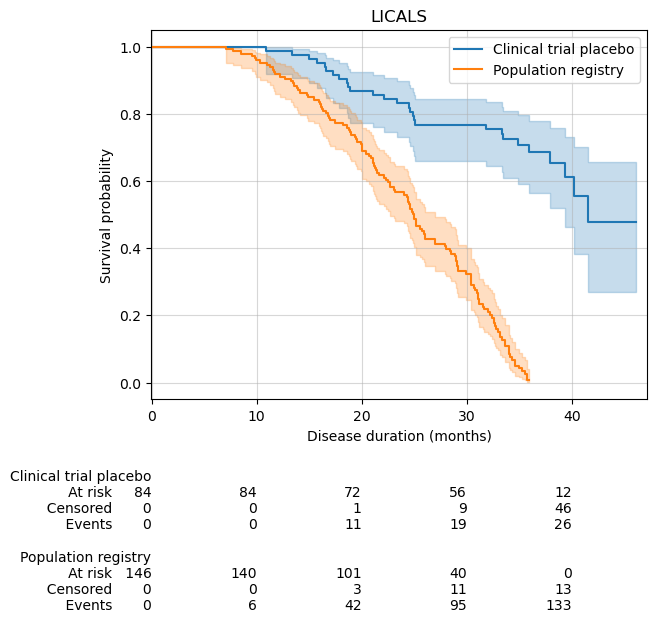

In [58]:
plot_km_placebo_vs_population(lica_pla, MND_lica_full, title = "LICALS")

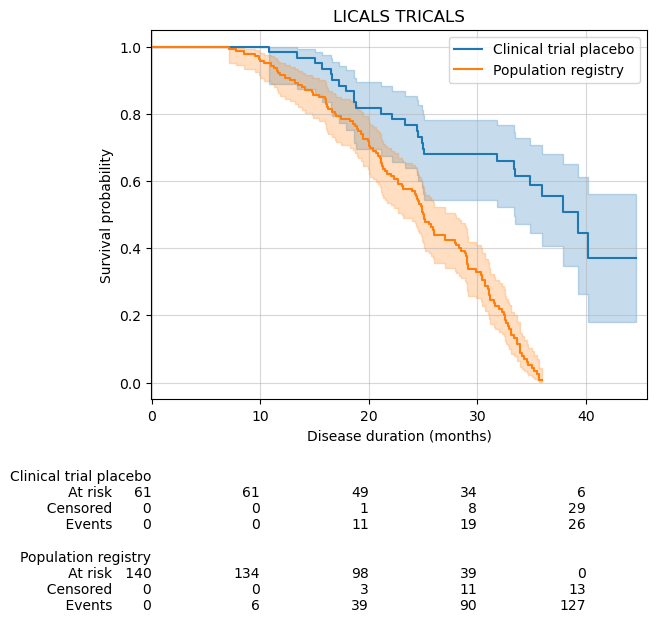

In [59]:
lica_pla_trical = lica_pla[(lica_pla['TRICALS'] >= -6) & (lica_pla['TRICALS'] <= -2)]
MND_lica_full_trical = MND_lica_full[(MND_lica_full['TRICALS'] >= -6) & (MND_lica_full['TRICALS'] <= -2)]
miro_pla_trical.head(2)

plot_km_placebo_vs_population(lica_pla_trical, MND_lica_full_trical, title = "LICALS TRICALS")

In [ ]:
plot_km_placebo_vs_population(ril_301_pla, MND_rilu_full, title = "RILUZOLE")

In [ ]:
plot_km_placebo_vs_population(proact_miro_pla, MND_miro_full, title = "MIROCALS PROACT")

In [ ]:
plot_km_placebo_vs_population(proact_lica_pla, MND_lica_full, title = "LICALS PROACT")

In [ ]:
# !pip install numpy pandas matplotlib lifelines scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

We assume that delayed entry =  diagnostic delay. that is, we assume that a patient entered a study when they were first diagnosed. Although this is not the case, it is a reasonable approximation.

### **Helper functions (KM + RMST + plotting)**

In [ ]:
def km_fit(df, label, entry_dxdiag_col = "entry", time_col = "t_obs", event_col = "event", weights = None):
    kmf = KaplanMeierFitter()
    kmf.fit(durations = df[time_col], event_observed = df[event_col], entry = df[entry_dxdiag_col],
                label = label, weights = weights)
    return kmf


def rmst_from_km(kmf, tau):
    sf = kmf.survival_function_
    times = sf.index.values
    surv = sf.iloc[:, 0].values

    grid_t = np.unique(np.concatenate(([0], times[times <= tau], [tau])))

    # interpolate survival values
    s_at = np.interp(grid_t, times, surv, left=1.0, right=surv[-1])

    # trapezoidal integration
    area = np.trapezoid(s_at, grid_t)
    return area

def plot_two_km(km1, km2, title):
    fig, ax =  plt.subplots()

    km1.plot_survival_function(ax=ax, ci_show = True)
    km2.plot_survival_function(ax=ax, ci_show = True)
    ax.set_title(title)
    ax.set_xlabel("Disease duration (months)")
    ax.set_ylabel("Survival probability")
    ax.grid(True, alpha=0.4)

    add_at_risk_counts(km1, km2, ax=ax)
    plt.show()


Yes, Restricted Mean Survival Time (RMST) is commonly calculated using Kaplan-Meier (KM) curves. 

It represents the area under the Kaplan-Meier survival curve up to a specific, pre-specified time point, t0,

 serving as a robust, non-parametric alternative to hazard ratios that indicates average event-free survival

##### **Crude "trial vs eligible restry" bias: KM + RMST + Cox**

In [ ]:
miro_pla.columns

In [ ]:
miro_pla = miro_pla[['subject_id', 'Event', 'Disease_Duration','Age','Diagnostic_Delay','Sex', 'Onset_site',
                       'TRICALS']]
miro_pla["Source"] = "Trial_placebo"
# print(f"{miro_pla.head(1)}\n")

MND_miro_full["Source"] = "Registry"
# print(f"\n{MND_miro_full.head(1)}")

comb_miro = pd.concat([miro_pla, MND_miro_full], ignore_index=True)
comb_miro["S_trial"] = (comb_miro["Source"] == "Trial_placebo").astype(int)
comb_miro.head(2)

In [ ]:
lica_pla = lica_pla[['subject_id', 'Event', 'Disease_Duration','Age','Diagnostic_Delay','Sex', 'Onset_site',
                       'TRICALS']]
lica_pla["Source"] = "Trial_placebo"
# print(f"{lica_pla.head(1)}\n")

MND_lica_full["Source"] = "Registry"
# print(f"\n{MND_lica_full.head(1)}")

comb_lica = pd.concat([lica_pla, MND_lica_full], ignore_index=True)
comb_lica["S_trial"] = (comb_lica["Source"] == "Trial_placebo").astype(int)
comb_lica.head(2)

In [ ]:
proact_miro_pla["Source"] = "Trial_placebo"
# print(f"{lica_pla.head(1)}\n")

MND_miro_full["Source"] = "Registry"
# print(f"\n{MND_lica_full.head(1)}")

comb_proact_miro = pd.concat([proact_miro_pla, MND_miro_full], ignore_index=True)
comb_proact_miro["S_trial"] = (comb_proact_miro["Source"] == "Trial_placebo").astype(int)
comb_proact_miro.head(2)

In [ ]:
proact_lica_pla["Source"] = "Trial_placebo"
# print(f"{lica_pla.head(1)}\n")

MND_lica_full["Source"] = "Registry"
# print(f"\n{MND_lica_full.head(1)}")

comb_proact_lica = pd.concat([proact_lica_pla, MND_lica_full], ignore_index=True)
comb_proact_lica["S_trial"] = (comb_proact_lica["Source"] == "Trial_placebo").astype(int)
comb_proact_lica.head(2)

#### **K-M curves with delayed entry**

In [ ]:
km_trial = km_fit(miro_pla, entry_dxdiag_col = "Diagnostic_Delay", time_col = "Disease_Duration", event_col = "Event",
                label="Clinical trial placebo")

km_reg = km_fit(MND_miro_full, entry_dxdiag_col = "Diagnostic_Delay", time_col = "Disease_Duration", event_col = "Event",
                label="Population registry")

print("Group 1 median:", km_trial.median_survival_time_)
print("Group 2 median:", km_reg.median_survival_time_)

plot_two_km(km_trial, km_reg, title = "MIROCALS: Delayed entry")

#### **Without delayed entry**

In [ ]:
km_miro_c = km_curve_fit(miro_pla, "Clinical trial placebo")
km_mnd_miro_p = km_curve_fit(MND_miro_full, "Population registry")

mst_miro_c = km_miro_c.median_survival_time_
mst_mnd_miro_p = km_mnd_miro_p.median_survival_time_

print(f"Median survival time | Trial: {mst_miro_c:.2f}, Registry: {mst_mnd_miro_p:.2f}, diff: {mst_miro_c - mst_mnd_miro_p:.2f} months")


In [ ]:
km_lica_c = km_curve_fit(lica_pla, "Clinical trial placebo")
km_mnd_lica_p = km_curve_fit(MND_lica_full, "Population registry")

mst_lica_c = km_lica_c.median_survival_time_
mst_mnd_lica_p = km_mnd_lica_p.median_survival_time_

print(f"Median survival time | Trial: {mst_lica_c:.2f}, Registry: {mst_mnd_lica_p:.2f}, diff: {mst_lica_c - mst_mnd_lica_p:.2f} months")

In [ ]:
km_pro_miro_c = km_curve_fit(proact_miro_pla, "Clinical trial placebo")
km_mnd_miro_p = km_curve_fit(MND_miro_full, "Population registry")

mst_pro_miro_c = km_pro_miro_c.median_survival_time_
mst_mnd_miro_p = km_mnd_miro_p.median_survival_time_

print(f"Median survival time | Trial: {mst_pro_miro_c:.2f}, Registry: {mst_mnd_miro_p:.2f}, diff: {mst_pro_miro_c - mst_mnd_miro_p:.2f} months")

In [ ]:
km_pro_lica_c = km_curve_fit(proact_lica_pla, "Clinical trial placebo")
km_mnd_lica_p = km_curve_fit(MND_lica_full, "Population registry")

mst_pro_lica_c = km_pro_lica_c.median_survival_time_
mst_mnd_lica_p = km_mnd_lica_p.median_survival_time_

print(f"Median survival time | Trial: {mst_pro_lica_c:.2f}, Registry: {mst_mnd_lica_p:.2f}, diff: {mst_pro_lica_c - mst_mnd_lica_p:.2f} months")

In [ ]:
# plot_km_placebo_vs_population(miro_pla, MND_miro_full, title = "MIROCALS")

In [ ]:
# RMST difference at tau = 19 months (median survival time for registry data)
tau = km_reg.median_survival_time_
rmst_trial = rmst_from_km(km_trial, tau)
rmst_reg = rmst_from_km(km_reg, tau)
print(f"RMST @ {tau:.2f} months | Trial: {rmst_trial:.2f}, Registry: {rmst_reg:.2f}, diff: {rmst_trial-rmst_reg:.2f} months")


In [ ]:
# RMST difference at tau = 20 months (median survival time for registry data without delayed entry)
tau = km_mnd_miro_p.median_survival_time_
rmst_miro_c = rmst_from_km(km_miro_c, tau)
rmst_mnd_miro_p = rmst_from_km(km_mnd_miro_p, tau)
print(f"RMST @ {tau:.2f} months | Trial: {rmst_miro_c:.2f}, Registry: {rmst_mnd_miro_p:.2f}, diff: {rmst_miro_c - rmst_mnd_miro_p:.2f} months")

In [ ]:
# RMST difference at tau = 20 months (median survival time for registry data without delayed entry)
tau = km_mnd_lica_p.median_survival_time_
rmst_lica_c = rmst_from_km(km_lica_c, tau)
rmst_mnd_lica_p = rmst_from_km(km_mnd_lica_p, tau)
print(f"RMST @ {tau:.2f} months | Trial: {rmst_lica_c:.2f}, Registry: {rmst_mnd_lica_p:.2f}, diff: {rmst_lica_c - rmst_mnd_lica_p:.2f} months")

In [ ]:
# RMST difference at tau = 20 months (median survival time for registry data without delayed entry)
tau = km_mnd_miro_p.median_survival_time_
rmst_pro_miro_c = rmst_from_km(km_pro_miro_c, tau)
rmst_mnd_miro_p = rmst_from_km(km_mnd_miro_p, tau)
print(f"RMST @ {tau:.2f} months | Trial: {rmst_pro_miro_c:.2f}, Registry: {rmst_mnd_miro_p:.2f}, diff: {rmst_pro_miro_c - rmst_mnd_miro_p:.2f} months")

In [ ]:
# RMST difference at tau = 20 months (median survival time for registry data without delayed entry)
tau = km_mnd_lica_p.median_survival_time_
rmst_pro_lica_c = rmst_from_km(km_pro_lica_c, tau)
rmst_mnd_lica_p = rmst_from_km(km_mnd_lica_p, tau)
print(f"RMST @ {tau:.2f} months | Trial: {rmst_pro_lica_c:.2f}, Registry: {rmst_mnd_lica_p:.2f}, diff: {rmst_pro_lica_c - rmst_mnd_lica_p:.2f} months")

##### **Log rank test**

In [ ]:
trial = comb_miro[comb_miro['S_trial'] == 1]
registry = comb_miro[comb_miro['S_trial'] == 0]

result = logrank_test(
    trial['Disease_Duration'], registry['Disease_Duration'],
    event_observed_A = trial['Event'],
    event_observed_B = registry['Event']
)

print(result.summary)

In [ ]:
trial = comb_lica[comb_lica['S_trial'] == 1]
registry = comb_lica[comb_lica['S_trial'] == 0]

result = logrank_test(
    trial['Disease_Duration'], registry['Disease_Duration'],
    event_observed_A = trial['Event'],
    event_observed_B = registry['Event']
)

print(result.summary)

In [ ]:
trial = comb_proact_miro[comb_proact_miro['S_trial'] == 1]
registry = comb_proact_miro[comb_proact_miro['S_trial'] == 0]

result = logrank_test(
    trial['Disease_Duration'], registry['Disease_Duration'],
    event_observed_A = trial['Event'],
    event_observed_B = registry['Event']
)

print(result.summary)

In [ ]:
trial = comb_proact_lica[comb_proact_lica['S_trial'] == 1]
registry = comb_proact_lica[comb_proact_lica['S_trial'] == 0]

result = logrank_test(
    trial['Disease_Duration'], registry['Disease_Duration'],
    event_observed_A = trial['Event'],
    event_observed_B = registry['Event']
)

print(result.summary)

##### **Cox model with delayed entry**

In [ ]:
# Fit Cox with entry delay
# cox model with only s_trial, with left truncation
cph = CoxPHFitter()
cph.fit(comb_miro[['Event', 'Disease_Duration', 'Diagnostic_Delay', 'S_trial']],
        duration_col = 'Disease_Duration', event_col = 'Event', entry_col = 'Diagnostic_Delay')
cph.print_summary()

Interpretation:

HR < 1 for trial_group means the trial cohort has a lower hazard of death

HR > 1 means the trial cohort has a higher hazard of death

##### **Cox model with case mix adjusted survival bias (with delayed entry)**
##### This answers: Is trial vs registry survival different after correcting for survivorship to diagnosis?

In [ ]:
comb_miro['Sex_male'] = (comb_miro['Sex'] == 'Male').astype(int)
comb_miro['Onset_limb'] = (comb_miro['Onset_site'] == 'Limb').astype(int)
comb_miro.columns

In [ ]:
comb_lica['Sex_male'] = (comb_lica['Sex'] == 'Male').astype(int)
comb_lica['Onset_limb'] = (comb_lica['Onset_site'] == 'Limb').astype(int)
# comb_lica.columns

In [ ]:
comb_proact_miro['Sex_male'] = (comb_proact_miro['Sex'] == 'Male').astype(int)
comb_proact_miro['Onset_limb'] = (comb_proact_miro['Onset_site'] == 'Limb').astype(int)

comb_proact_lica['Sex_male'] = (comb_proact_lica['Sex'] == 'Male').astype(int)
comb_proact_lica['Onset_limb'] = (comb_proact_lica['Onset_site'] == 'Limb').astype(int)

In [ ]:
# comb_proact_lica.info()

In [ ]:
# Model A (cleanest for interpretation): Diagnostic_Delay not a covariate
covars = ["S_trial", "Age", "Sex_male", "Onset_limb"]

cph_adj = CoxPHFitter()
cph_adj.fit(comb_miro[["Diagnostic_Delay", "Disease_Duration", "Event"] + covars],
        duration_col="Disease_Duration", event_col="Event", entry_col="Diagnostic_Delay")
cph_adj.print_summary()

The association of diagnostic delay with hazard among people who have already survived to diagnosis (i.e., conditional on 𝑇 > 𝐸).

Use diagnostic delay for entry and include it as a covariate.

This answers:
Is there still a trial vs registry difference even after accounting for the prognostic information carried by diagnostic delay?

If the “trial advantage” shrinks a lot from A → B, that tells you diagnostic delay is a big part of measured selection/case-mix.

##### **Cox model without delayed entry**

In [ ]:
# Fit Cox without entry delay
# cox model with only s_trial, without left truncation
cph1 = CoxPHFitter()
cph1.fit(comb_miro[['Event', 'Disease_Duration', 'S_trial']],
        duration_col = 'Disease_Duration', event_col = 'Event')
cph1.print_summary()

In [ ]:
# Fit Cox without entry delay
# cox model with only s_trial, without left truncation
cph2 = CoxPHFitter()
cph2.fit(comb_lica[['Event', 'Disease_Duration', 'S_trial']],
        duration_col = 'Disease_Duration', event_col = 'Event')
cph2.print_summary()


from lifelines.statistics import proportional_hazard_test

results = proportional_hazard_test(cph2, comb_lica[['Event', 'Disease_Duration', 'S_trial']], time_transform='rank')

print(results.summary)

Interpretation:

Patients in the clinical trial placebo cohort have about 85% lower hazard of death than registry patients.

In [ ]:
cph2 = CoxPHFitter()
cph2.fit(comb_proact_miro[['Event', 'Disease_Duration', 'S_trial']],
        duration_col = 'Disease_Duration', event_col = 'Event')
cph2.print_summary()

In [ ]:
cph2 = CoxPHFitter()
cph2.fit(comb_proact_lica[['Event', 'Disease_Duration', 'S_trial']],
        duration_col = 'Disease_Duration', event_col = 'Event')
cph2.print_summary()

##### **Cox model with case mix adjusted survival bias (without delayed entry)**
##### This answers: Is trial vs registry survival different after adjusting for other covariate?

In [ ]:
# Model B: Diagnostic_Delay as covariate, without delayed entry
covars1 = ["S_trial", "Age", "Sex_male", "Onset_limb", "Diagnostic_Delay"]

cph_adj1 = CoxPHFitter()
cph_adj1.fit(comb_miro[["Disease_Duration", "Event"] + covars1],
        duration_col="Disease_Duration", event_col="Event")
cph_adj1.print_summary()

results = proportional_hazard_test(cph_adj1, comb_miro[["Disease_Duration", "Event"] + covars1], time_transform='rank')

print(results.summary)

In [ ]:
# Model B: Diagnostic_Delay as covariate, without delayed entry
covars2 = ["S_trial", "Age", "Sex_male", "Onset_limb", "Diagnostic_Delay"]

cph_adj2 = CoxPHFitter()
cph_adj2.fit(comb_lica[["Disease_Duration", "Event"] + covars2],
        duration_col="Disease_Duration", event_col="Event")
cph_adj2.print_summary()

In [ ]:
# comb_proact_miro.info()

In [ ]:
# Model B: Diagnostic_Delay as covariate, without delayed entry
covars2 = ["S_trial", "Age", "Sex_male", "Onset_limb", "Diagnostic_Delay"]

cph_adj2 = CoxPHFitter()
cph_adj2.fit(comb_proact_miro[["Disease_Duration", "Event"] + covars2],
        duration_col="Disease_Duration", event_col="Event")
cph_adj2.print_summary()

In [ ]:
# Model B: Diagnostic_Delay as covariate, without delayed entry
covars2 = ["S_trial", "Age", "Sex_male", "Onset_limb", "Diagnostic_Delay"]

cph_adj2 = CoxPHFitter()
cph_adj2.fit(comb_proact_lica[["Disease_Duration", "Event"] + covars2],
        duration_col="Disease_Duration", event_col="Event")
cph_adj2.print_summary()

## **Second attempt on Bootstrapping, calibration slope, regression coefficients, CI.**

In [ ]:
# ============================================================
# HELPERS (DROP-IN): automatic direction detection + consistent
# scoring for C-index, slope, shrinkage, and reporting.
#
# Key conventions enforced:
#   - LP is extracted from stpm2 via type="lpmatrix" %*% coef
#   - A "risk score" is constructed so that:
#         mean(score | Event=1) > mean(score | Event=0)
#     i.e. higher score => higher hazard (worse prognosis)
#   - Concordance (Harrell's C) is computed using I(-score),
#     because survival::concordance assumes larger x => longer survival.
#   - Calibration slope is computed with score (higher => higher hazard).
#   - CITL at t0 is computed from predicted survival and KM; independent of score sign.
#
# These helpers are designed to eliminate all of the sign flip confusion
# you encountered (TRICALS changing the sign, etc.).
# ============================================================
# ============================================================
# R snippets setup

R = ro.r

# ---------- R snippets ----------
_r_conc_extract = R("""function(conc_obj) as.numeric(conc_obj$concordance[1])""")


_r_predict_surv_t0 = R("""
function(model, newdata, t0){
  n <- nrow(newdata)
  tmp <- transform(newdata, t0=rep(as.numeric(t0), n))
  as.numeric(predict(model, newdata=tmp, type="surv", timevar="t0"))
}
""")

_r_km_surv_t0 = R("""
function(df, t0){
  fit <- survival::survfit(survival::Surv(Disease_Duration, Event==1) ~ 1, data=df)
  ss <- summary(fit, times=as.numeric(t0))
  if(length(ss$surv)==0) return(NA_real_)
  as.numeric(ss$surv[1])
}
""")

_r_km_risk_ci_t0 = R("""
function(df, t0){
  fit <- survival::survfit(survival::Surv(Disease_Duration, Event==1) ~ 1, data=df)
  ss <- summary(fit, times=as.numeric(t0))
  if(length(ss$surv)==0) return(c(NA_real_, NA_real_, NA_real_))
  S  <- as.numeric(ss$surv[1])
  Lo <- as.numeric(ss$lower[1])
  Hi <- as.numeric(ss$upper[1])
  risk    <- 1 - S
  risk_lo <- 1 - Hi
  risk_hi <- 1 - Lo
  c(risk, risk_lo, risk_hi)
}
""")


# --- R function: IPCW recalibration at t0 ---
_r_ipcw_recal_t0 = R("""
function(time, status, p_pred, t0, estimate_slope=FALSE){
  # time: follow-up time
  # status: 1=event, 0=censored
  # p_pred: predicted risk at t0 (individual)
  # t0: horizon
  # estimate_slope: if TRUE, fit intercept + slope; else intercept only with offset

  time   <- as.numeric(time)
  status <- as.integer(status)
  status <- ifelse(status == 1L, 1L, 0L)
  status <- as.integer(status)

  p_pred <- as.numeric(p_pred)
  t0     <- as.numeric(t0)

  # clip predicted risks to avoid +/-Inf logits
  eps <- 1e-12
  p_pred <- pmin(pmax(p_pred, eps), 1 - eps)

  # --- estimate censoring survival G(t) via KM on censoring indicator ---
  # censoring event: 1 if censored, 0 otherwise
  censor_event <- 1L - status
  fitG <- survival::survfit(survival::Surv(time, censor_event) ~ 1)

  # helper to get G(u) at specific times u using summary
  G_at <- function(u){
    ss <- summary(fitG, times=u)
    if(length(ss$surv)==0){
      # if u is beyond last event time, KM stays at last survival
      return(tail(fitG$surv, 1))
    }
    return(ss$surv[1])
  }

  # build weights
  w <- rep(0, length(time))
  Y <- ifelse(time <= t0 & status == 1L, 1L, 0L)
  Y <- as.integer(Y)
  w <- as.numeric(w)

  # Y <- as.integer(time <= t0 & status == 1L)

  # events before/at t0: w = 1 / G(Ti)
  idx_event <- which(time <= t0 & status == 1L)
  if(length(idx_event) > 0){
    Gi <- sapply(time[idx_event], G_at)
    w[idx_event] <- 1 / pmax(Gi, eps)
  }

  # event-free at t0 (known): time >= t0 => w = 1 / G(t0)
  idx_free <- which(time >= t0)
  if(length(idx_free) > 0){
    Gt0 <- G_at(t0)
    w[idx_free] <- 1 / pmax(Gt0, eps)
  }

  # fit logistic recalibration
  lp_pred <- qlogis(p_pred)

  if(!estimate_slope){
    fit <- stats::glm(Y ~ 1 + offset(lp_pred),
                      family=stats::quasibinomial(),
                      weights=w)
    alpha <- stats::coef(fit)[1]
    return(list(alpha=as.numeric(alpha),
                model=fit))
  } else {
    fit <- stats::glm(Y ~ lp_pred,
                      family=stats::quasibinomial(),
                      weights=w)
    alpha <- stats::coef(fit)[1]
    beta  <- stats::coef(fit)[2]
    return(list(alpha=as.numeric(alpha),
                beta=as.numeric(beta),
                model=fit))
  }
}
""")

_r_km_risk_ci_t0_robust = R("""
function(df, t0){
  fit <- survival::survfit(survival::Surv(Disease_Duration, Event==1) ~ 1, data=df)
  # pick the largest time in fit$time that is <= t0
  tt <- fit$time
  if(length(tt)==0) return(c(NA_real_, NA_real_, NA_real_))
  t_use <- max(tt[tt <= as.numeric(t0)], na.rm=TRUE)
  if(!is.finite(t_use)) return(c(NA_real_, NA_real_, NA_real_))
  ss <- summary(fit, times=t_use)
  if(length(ss$surv)==0) return(c(NA_real_, NA_real_, NA_real_))
  S  <- as.numeric(ss$surv[1])
  Lo <- as.numeric(ss$lower[1])
  Hi <- as.numeric(ss$upper[1])
  risk    <- 1 - S
  risk_lo <- 1 - Hi
  risk_hi <- 1 - Lo
  c(risk, risk_lo, risk_hi)
}
""")

def km_risk_ci_at_t0(r_df_sub, t0_months: int) -> tuple[float, float, float]:
    out = np.asarray(_r_km_risk_ci_t0_robust(r_df_sub, float(t0_months)), dtype=float)
    if np.any(~np.isfinite(out)):
        return (np.nan, np.nan, np.nan)
    return (float(out[0]), float(out[1]), float(out[2]))


# from rpy2.robjects.vectors import FloatVector, IntVector

def ipcw_calibration_intercept_t0_stpm2(
    model,
    r_df,
    t0_months: float,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
) -> float:
    # predicted risk at t0 from stpm2 (sign independent)
    S_pred = predict_surv_at_t0(model, r_df, t0_months)
    p_pred = 1.0 - np.asarray(S_pred, float)
    p_pred = np.clip(p_pred, 1e-12, 1 - 1e-12)

    # Extract from R df -> numpy, then wrap as R vectors
    time_np   = np.asarray(r_df.rx2(time_col), dtype=float)
    status_np = np.asarray(r_df.rx2(event_col), dtype=int)

    time_r   = FloatVector(time_np.tolist())
    status_r = IntVector(status_np.tolist())
    p_pred_r = FloatVector(p_pred.tolist())

    out = _r_ipcw_recal_t0(time_r, status_r, p_pred_r, float(t0_months), False)
    return float(out.rx2("alpha")[0])


def ipcw_intercept_and_slope_t0_stpm2(
    model,
    r_df,
    t0_months: float,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
):
    S_pred = predict_surv_at_t0(model, r_df, t0_months)
    p_pred = 1.0 - np.asarray(S_pred, float)
    p_pred = np.clip(p_pred, 1e-12, 1 - 1e-12)

    time_np   = np.asarray(r_df.rx2(time_col), dtype=float)
    status_np = np.asarray(r_df.rx2(event_col), dtype=int)

    time_r   = FloatVector(time_np.tolist())
    status_r = IntVector(status_np.tolist())
    p_pred_r = FloatVector(p_pred.tolist())

    out = _r_ipcw_recal_t0(time_r, status_r, p_pred_r, float(t0_months), True)
    alpha = float(out.rx2("alpha")[0])
    beta  = float(out.rx2("beta")[0])
    return alpha, beta


def ipcw_citl_from_pred_risk(
    r_df,
    p_pred: np.ndarray,
    t0_months: float,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
) -> float:
    p_pred = np.asarray(p_pred, float)
    p_pred = np.clip(p_pred, 1e-12, 1 - 1e-12)

    time_np   = np.asarray(r_df.rx2(time_col), dtype=float)
    status_np = np.asarray(r_df.rx2(event_col), dtype=int)

    time_r   = FloatVector(time_np.tolist())
    status_r = IntVector(status_np.tolist())
    p_pred_r = FloatVector(p_pred.tolist())

    out = _r_ipcw_recal_t0(time_r, status_r, p_pred_r, float(t0_months), False)
    return float(out.rx2("alpha")[0])


# ============================================================
# Conversion helper
# ============================================================ full
def to_r_df(df: pd.DataFrame):
    with localconverter(default_converter + pandas2ri.converter):
        return pandas2ri.py2rpy(df)

# ============================================================
# LP / Score helpers
# ============================================================

def predict_pi_from_stpm2(model, r_df, vars_final: list[str]) -> np.ndarray:
    """
    Prognostic index PI(x) = x^T beta using ONLY covariate coefficients
    that match vars_final exactly.
    r_df must contain those columns as numeric.
    """
    coef_vec = ro.r["coef"](model)
    coef_names = list(map(str, ro.r["names"](coef_vec)))
    b = np.asarray(list(coef_vec), dtype=float)
    coef_map = dict(zip(coef_names, b))

    missing = [v for v in vars_final if v not in coef_map]
    if missing:
        raise ValueError(
            f"vars_final not found in coef(model): {missing}\n"
            f"First 40 coef names: {coef_names[:40]}"
        )

    # Extract X from r_df (as numpy)
    Xcols = []
    for v in vars_final:
        Xcols.append(np.asarray(r_df.rx2(v), dtype=float))
    X = np.column_stack(Xcols)  # n x p

    beta = np.asarray([coef_map[v] for v in vars_final], dtype=float)
    return X @ beta


def _event_mask_from_r(r_df, event_col: str = "Event") -> np.ndarray:
    """Extract Event vector from an R df and return boolean mask event==1."""
    ev = np.asarray(r_df.rx2(event_col), dtype=float)
    return (ev == 1)

def choose_score_sign_from_lp(
    lp: np.ndarray,
    event_mask: np.ndarray,
) -> int:
    """
    Decide whether score should be LP (+1) or -LP (-1)
    so that mean(score|event=1) > mean(score|event=0).
    Returns sign s in {+1, -1} such that score = s * lp.
    """
    lp = np.asarray(lp, float)
    m1 = float(np.mean(lp[event_mask])) if np.any(event_mask) else np.nan
    m0 = float(np.mean(lp[~event_mask])) if np.any(~event_mask) else np.nan

    # If either group missing, default to +1 (no flip) but warn by returning +1
    if not np.isfinite(m1) or not np.isfinite(m0):
        return +1

    # Want score higher in event group. If lp already higher in events => +1 else -1
    return +1 if (m1 > m0) else -1


def risk_score_stpm2(
    model,
    r_df,
    vars_final: list[str],          # <-- REQUIRED NOW
    event_col: str = "Event",
    sign: int | None = None,
    return_details: bool = False,
):
    """
    Risk score based on PI(x)=x^T beta (covariates only, no baseline spline leakage).
    Higher score => higher hazard (worse).
    """
    pi = predict_pi_from_stpm2(model, r_df, vars_final=vars_final)
    event_mask = _event_mask_from_r(r_df, event_col=event_col)

    if sign is None:
        sign = choose_score_sign_from_lp(pi, event_mask)  # same logic, now applied to PI

    score = sign * pi

    if not return_details:
        return score

    m1_pi = float(np.mean(pi[event_mask])) if np.any(event_mask) else np.nan
    m0_pi = float(np.mean(pi[~event_mask])) if np.any(~event_mask) else np.nan
    m1_sc = float(np.mean(score[event_mask])) if np.any(event_mask) else np.nan
    m0_sc = float(np.mean(score[~event_mask])) if np.any(~event_mask) else np.nan

    return score, {
        "chosen_sign": int(sign),
        "mean_pi_event1": m1_pi,
        "mean_pi_event0": m0_pi,
        "mean_score_event1": m1_sc,
        "mean_score_event0": m0_sc,
    }

# ============================================================
# Performance metrics (direction-safe)
# ============================================================
def cindex_from_risk_score(r_df, score: np.ndarray) -> float:
    """
    Harrell's C computed consistently.
    survival::concordance assumes larger x => longer survival, so use -score.
    """
    r_tmp = R("transform")(r_df, score=FloatVector(np.asarray(score, float).tolist()))
    conc_obj = survival.concordance(
        Formula("Surv(Disease_Duration, Event==1) ~ I(-score)"),
        data=r_tmp
    )
    return float(_r_conc_extract(conc_obj)[0])

def slope_from_risk_score(r_df, score: np.ndarray) -> float:
    """
    Calibration slope via Cox model using risk score (higher => higher hazard).
    """
    r_tmp = R("transform")(r_df, score=FloatVector(np.asarray(score, float).tolist()))
    cal = survival.coxph(
        Formula("Surv(Disease_Duration, Event==1) ~ score"),
        data=r_tmp
    )
    return float(np.asarray(R["coef"](cal), dtype=float)[0])



# ============================================================
# CITL and survival-at-t0 (sign independent)
# ============================================================
def predict_surv_at_t0(model, r_df, t0_months: float) -> np.ndarray:
    return np.asarray(_r_predict_surv_t0(model, r_df, float(t0_months)), dtype=float)

def _logit(p: float) -> float:
    p = float(np.clip(p, 1e-12, 1-1e-12))
    return float(np.log(p/(1-p)))

def km_surv_at_t0(r_df, t0_months: float) -> float:
    return float(_r_km_surv_t0(r_df, float(t0_months))[0])

def citl_at_t0(model, r_df, t0_months: int) -> float:
    """
    CITL(t0) = logit(p_obs(t0)) - logit(mean(p_pred(t0)))
    p_pred(t0) = 1 - S_pred(t0)
    p_obs(t0)  = 1 - S_KM(t0)
    """
    S_pred = predict_surv_at_t0(model, r_df, t0_months)
    p_pred = 1.0 - S_pred
    p_bar = float(np.mean(p_pred))

    S_km = km_surv_at_t0(r_df, t0_months)
    if not np.isfinite(S_km):
        return np.nan
    p_obs = 1.0 - float(S_km)
    return float(_logit(p_obs) - _logit(p_bar))


def delta_logit_km_vs_meanpred_at_t0(model, r_df, t0_months: int) -> float:
    # your existing citl_at_t0() exactly as is
    return citl_at_t0(model, r_df, t0_months)


def citl_ipcw_at_t0(model, r_df, t0_months: int) -> float:
    return ipcw_calibration_intercept_t0_stpm2(model, r_df, t0_months)

# ============================================================
# Shrinkage helper (valid only when slope_corr > 0)
# ============================================================


def uniform_shrinkage_from_slope(slope_corr: float) -> float:
    """
    Uniform shrinkage factor s ≈ optimism-corrected calibration slope.

    - If slope_corr < 1: overfitting -> shrink (s < 1)
    - If slope_corr > 1: underfitting -> do not "anti-shrink" -> cap at 1
    """
    if not np.isfinite(slope_corr) or slope_corr <= 0:
        return 1.0
    return float(min(1.0, slope_corr))

# ============================================================
# Convenience: evaluate a fitted stpm2 model on a dataset
# (apparent metrics; fully direction-safe)
# ============================================================
def evaluate_stpm2_apparent(
    model,
    r_df,
    vars_final,
    t0_months: int = 24,
    event_col: str = "Event",
    sign: int | None = None,   # optional: fix sign for comparability
    verbose: bool = True,
):
    score, info = risk_score_stpm2(model, r_df, vars_final=vars_final, event_col=event_col, sign=sign, return_details=True)

    c = cindex_from_risk_score(r_df, score)
    s = slope_from_risk_score(r_df, score)
    # citl = citl_at_t0(model, r_df, t0_months)
    citl_ipcw = citl_ipcw_at_t0(model, r_df, t0_months)
    citl_simple = delta_logit_km_vs_meanpred_at_t0(model, r_df, t0_months)


    if verbose:
        print("Score sign chosen:", info["chosen_sign"])
        print("Mean LP event=1 / event=0:", info["mean_lp_event1"], info["mean_lp_event0"])
        print("Mean score event=1 / event=0:", info["mean_score_event1"], info["mean_score_event0"])
        print("C-index:", c)
        print("Slope:", s)
        print("CITL:", citl)

    return {"cindex": c, "slope": s, "citl_ipcw": citl_ipcw, "citl_simple": citl_simple, "score_sign": info["chosen_sign"], "details": info}


# ============================================================
# (Optional) Calibration bins utility (KM risk with CI)
# ============================================================


def calibration_bins_km(r_df, pred_risk: np.ndarray, t0_months: int, n_bins: int = 5) -> pd.DataFrame:
    df = pd.DataFrame({"pred": np.asarray(pred_risk, float)})
    df["bin"] = pd.qcut(df["pred"], q=n_bins, duplicates="drop")

    rows = []
    for b in df["bin"].cat.categories:
        mask = (df["bin"] == b).to_numpy()
        idx0 = np.where(mask)[0]
        if len(idx0) == 0:
            continue
        r_sub = r_df.rx(IntVector((idx0 + 1).tolist()), True)
        risk, lo, hi = km_risk_ci_at_t0(r_sub, t0_months)
        if not np.isfinite(risk):
            continue
        rows.append({
            "bin": str(b),
            "n": int(mask.sum()),
            "mean_pred": float(df.loc[mask, "pred"].mean()),
            "obs_km": float(risk),
            "obs_lo": float(lo),
            "obs_hi": float(hi),
        })
    return pd.DataFrame(rows)


def calibration_bins_km_robust(r_df, pred_risk: np.ndarray, t0_months: int, n_bins: int = 5) -> pd.DataFrame:
    pr = np.asarray(pred_risk, float)
    df = pd.DataFrame({"pred": pr})
    df = df[np.isfinite(df["pred"])].copy()
    if df.empty:
        return pd.DataFrame()

    # Try qcut first
    try:
        df["bin"] = pd.qcut(df["pred"], q=n_bins, duplicates="drop")
        if df["bin"].isna().all() or len(df["bin"].cat.categories) < 2:
            raise ValueError("qcut collapsed bins")
    except Exception:
        # Fallback: rank-based bins (always works even with ties)
        r = df["pred"].rank(method="average")
        df["bin"] = pd.qcut(r, q=min(n_bins, df.shape[0]), duplicates="drop")

    rows = []
    for b in df["bin"].cat.categories:
        mask = (df["bin"] == b).to_numpy()
        idx0 = np.where(mask)[0]
        if len(idx0) == 0:
            continue
        r_sub = r_df.rx(IntVector((idx0 + 1).tolist()), True)
        risk, lo, hi = km_risk_ci_at_t0(r_sub, t0_months)
        if not np.isfinite(risk):
            continue
        rows.append({
            "bin": str(b),
            "n": int(mask.sum()),
            "mean_pred": float(df.loc[mask, "pred"].mean()),
            "obs_km": float(risk),
            "obs_lo": float(lo),
            "obs_hi": float(hi),
        })

    return pd.DataFrame(rows)

# ============================================================
# QUICK USAGE EXAMPLE (after you fit model_best_full)
# ============================================================
# with localconverter(default_converter + pandas2ri.converter):
#     r_full = pandas2ri.py2rpy(dev_df)
#
# out = evaluate_stpm2_apparent(model_best_full, r_full, t0_months=24, verbose=True)
# ============================================================

# ============================================================
# FULL-STRATEGY BOOTSTRAP VALIDATION (CORRECTED)
# ------------------------------------------------------------
# - Repeats the *entire* modelling strategy inside each bootstrap:
#     * backward AIC selection (with forced include/exclude)
#     * baseline spline df selection (over df_candidates)
# - Uses automatic direction detection for the risk score:
#     * score = s * LP, where s ∈ {+1, -1} chosen so that
#           mean(score | Event=1) > mean(score | Event=0)
# - FIXES SIGN CONSISTENCY:
#     * sign is chosen ON THE BOOTSTRAP SAMPLE (in-sample)
#     * the SAME sign is used when evaluating OUT-OF-BOOTSTRAP
#       on the original full dataset (no re-detection)
# - Computes optimism-corrected:
#     * C-index (via concordance with I(-score))
#     * Calibration slope (Cox on score)
#     * CITL at t0 (from predicted survival & KM)
#
# Requires your previously pasted helpers:
#   - backward_elimination_aic (SelectionResult)
#   - to_r_df
#   - risk_score_stpm2 (with sign optional)
#   - cindex_from_risk_score
#   - slope_from_risk_score
#   - citl_at_t0
#
# And assumes: rstpm2, survival, stats are available.
# ============================================================



R = ro.r

@dataclass
class FullStrategyValidationResult:
    best_vars_full: list[str]
    best_spline_df_full: int
    best_aic_full: float
    best_formula_full: str

    cindex_app: float
    slope_app: float
    citl_app: float

    cindex_corr: float
    slope_corr: float
    citl_corr: float

    cindex_ci: tuple[float, float]
    slope_ci: tuple[float, float]
    citl_ci: tuple[float, float]

    n_boot_success: int
    n_boot_fail: int

def _model_signature(vars_list: list[str], spline_df: int) -> str:
    key = f"df={spline_df}|" + "+".join(vars_list)
    return hashlib.md5(key.encode("utf-8")).hexdigest()

def backward_elimination_aic(
    df_python: pd.DataFrame,
    covariates: list[str],
    df_candidates: list[int],
    hard_include: list[str],
    hard_exclude: list[str] | None = None,
) -> SelectionResult:
    hard_exclude = list(hard_exclude or [])

    start_vars = [v for v in covariates if v not in set(hard_exclude)]
    for v in hard_include:
        if v not in start_vars and v not in set(hard_exclude):
            start_vars.append(v)

    forced = set(hard_include)
    r_df = _to_r_df(df_python.reset_index(drop=True))
    current_vars = start_vars[:]
    best: SelectionResult | None = None

    def better(a: SelectionResult, b: SelectionResult | None) -> bool:
        if b is None:
            return True
        return a.aic < b.aic - 1e-12

    while len(current_vars) >= 1:
        candidates: list[SelectionResult] = []

        for ddf in df_candidates:
            _, aic, fml = fit_stpm2_and_aic(r_df, current_vars, ddf)
            candidates.append(SelectionResult(current_vars[:], ddf, aic, fml))

        removable = [v for v in current_vars if v not in forced]
        for var in removable:
            test_vars = [v for v in current_vars if v != var]
            if not test_vars:
                continue
            for ddf in df_candidates:
                _, aic, fml = fit_stpm2_and_aic(r_df, test_vars, ddf)
                candidates.append(SelectionResult(test_vars[:], ddf, aic, fml))

        cand_best = None
        for c in candidates:
            if better(c, cand_best):
                cand_best = c

        if cand_best is None:
            break
        if best is not None and cand_best.aic >= best.aic - 1e-12:
            break

        best = cand_best
        current_vars = best.vars_final[:]
        if all(v in forced for v in current_vars):
            break

    if best is None:
        forced_list = [v for v in hard_include if v not in set(hard_exclude)]
        ddf = df_candidates[0]
        _, aic, fml = fit_stpm2_and_aic(r_df, forced_list, ddf)
        best = SelectionResult(forced_list, ddf, aic, fml)

    return best


def full_strategy_bootstrap_validation_corrected(
    df_full: pd.DataFrame,
    covariates: list[str],
    df_candidates: list[int],
    hard_include: list[str],
    hard_exclude: list[str] | None,
    t0_months: int,
    n_boot: int,
    random_state: int | None = None,
    event_col: str = "Event",
    verbose: bool = True,
):
    """
    Returns:
      res (FullStrategyValidationResult)
      diag (dict) with inclusion frequencies and selected df/model counts
      model_best_full (fitted stpm2 on full data using the chosen strategy)
    """
    hard_exclude = list(hard_exclude or [])
    rng = np.random.default_rng(random_state)

    df_full = df_full.reset_index(drop=True).copy()
    r_full = to_r_df(df_full)

    # ---------- Best model on full data (same selection strategy) ----------
    sel_full = backward_elimination_aic(
        df_python=df_full,
        covariates=covariates,
        df_candidates=df_candidates,
        hard_include=hard_include,
        hard_exclude=hard_exclude,
    )
    model_best_full = rstpm2.stpm2(Formula(sel_full.formula), data=r_full, df=sel_full.spline_df)

    # Apparent performance on full data:
    # IMPORTANT: sign is detected on the full data for the apparent score.
    # score_full, info_full = risk_score_stpm2(
    #     model_best_full, r_full, event_col=event_col, sign=None, return_details=True
    # )

    score_full, info_full = risk_score_stpm2(
    model_best_full, r_full,
    vars_final=sel_full.vars_final,
    event_col=event_col,
    sign=None,
    return_details=True)

    c_app = cindex_from_risk_score(r_full, score_full)
    s_app = slope_from_risk_score(r_full, score_full)
    citl_app = citl_ipcw_at_t0(model_best_full, r_full, t0_months)

    if verbose:
        print("\n[Apparent] score sign on FULL data:", info_full["chosen_sign"])
        print("[Apparent] mean LP event1/event0:", info_full["mean_pi_event1"], info_full["mean_pi_event0"])
        print("[Apparent] mean score event1/event0:", info_full["mean_score_event1"], info_full["mean_score_event0"])

    # ---------- Bootstrap loops (full strategy) ----------
    n = len(df_full)
    c_diffs, s_diffs, citl_diffs = [], [], []
    c_out_list, s_out_list, citl_out_list = [], [], []

    boot_coefs = []   # NEW: store coef vectors for final model only


    incl_counts = Counter()
    df_counts = Counter()
    model_counts = Counter()

    n_success = 0
    n_fail = 0

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        df_boot = df_full.iloc[idx].reset_index(drop=True)

        try:
            # (1) Repeat selection strategy within bootstrap
            sel_boot = backward_elimination_aic(
                df_python=df_boot,
                covariates=covariates,
                df_candidates=df_candidates,
                hard_include=hard_include,
                hard_exclude=hard_exclude,
            )
            incl_counts.update(sel_boot.vars_final)
            df_counts.update([sel_boot.spline_df])
            model_counts.update([_model_signature(sel_boot.vars_final, sel_boot.spline_df)])

            # (2) Fit the selected model in bootstrap sample
            r_boot = to_r_df(df_boot)
            model_boot = rstpm2.stpm2(Formula(sel_boot.formula), data=r_boot, df=sel_boot.spline_df)

            # --- store bootstrap coefficients ONLY if model structure matches final model ---
            if (
                sel_boot.vars_final == sel_full.vars_final and
                sel_boot.spline_df == sel_full.spline_df
            ):
                bvec = np.asarray(list(ro.r["coef"](model_boot)), dtype=float)
                boot_coefs.append(bvec)


            # (3) IN-sample evaluation (bootstrap)
            # Detect sign ON BOOTSTRAP SAMPLE
            # score_in, info_in = risk_score_stpm2(
            #     model_boot, r_boot, event_col=event_col, sign=None, return_details=True
            # )

            score_in, info_in = risk_score_stpm2(
                model_boot, r_boot,
                vars_final=sel_boot.vars_final,
                event_col=event_col,
                sign=None,
                return_details=True
            )

            sign_boot = info_in["chosen_sign"]

            c_in = cindex_from_risk_score(r_boot, score_in)
            s_in = slope_from_risk_score(r_boot, score_in)
            citl_in = citl_ipcw_at_t0(model_boot, r_boot, t0_months)

            # (4) OUT-of-sample evaluation (original full data)
            # FIX SIGN CONSISTENCY: re-use sign_boot, DO NOT re-detect on full data
            # score_out = risk_score_stpm2(
            #     model_boot, r_full, event_col=event_col, sign=sign_boot, return_details=False
            # )

            score_out = risk_score_stpm2(
                model_boot, r_full,
                vars_final=sel_boot.vars_final,
                event_col=event_col,
                sign=sign_boot,
                return_details=False
            )

            c_out = cindex_from_risk_score(r_full, score_out)
            s_out = slope_from_risk_score(r_full, score_out)
            citl_out = citl_ipcw_at_t0(model_boot, r_full, t0_months)

            c_diffs.append(c_in - c_out)
            s_diffs.append(s_in - s_out)
            citl_diffs.append(citl_in - citl_out)

            c_out_list.append(c_out)
            s_out_list.append(s_out)
            citl_out_list.append(citl_out)

            n_success += 1

        except Exception:
            n_fail += 1

    # ---------- Optimism correction ----------
    if n_success > 0:
        c_corr = c_app - float(np.nanmean(c_diffs))
        s_corr = s_app - float(np.nanmean(s_diffs))
        citl_corr = citl_app - float(np.nanmean(citl_diffs))

        c_ci = tuple(np.nanpercentile(c_out_list, [2.5, 97.5]).astype(float))
        s_ci = tuple(np.nanpercentile(s_out_list, [2.5, 97.5]).astype(float))
        citl_ci = tuple(np.nanpercentile(citl_out_list, [2.5, 97.5]).astype(float))
    else:
        c_corr, s_corr, citl_corr = c_app, s_app, citl_app
        c_ci = (np.nan, np.nan)
        s_ci = (np.nan, np.nan)
        citl_ci = (np.nan, np.nan)

    denom = max(1, n_success)
    universe = (set(covariates) | set(hard_include)) - set(hard_exclude)
    incl_freq = {v: incl_counts[v] / denom for v in universe}

    res = FullStrategyValidationResult(
        best_vars_full=sel_full.vars_final,
        best_spline_df_full=int(sel_full.spline_df),
        best_aic_full=float(sel_full.aic),
        best_formula_full=sel_full.formula,

        cindex_app=float(c_app),
        slope_app=float(s_app),
        citl_app=float(citl_app),

        cindex_corr=float(c_corr),
        slope_corr=float(s_corr),
        citl_corr=float(citl_corr),

        cindex_ci=(float(c_ci[0]), float(c_ci[1])),
        slope_ci=(float(s_ci[0]), float(s_ci[1])),
        citl_ci=(float(citl_ci[0]), float(citl_ci[1])),

        n_boot_success=int(n_success),
        n_boot_fail=int(n_fail),
    )

    diag = {
        "selection_inclusion_counts": incl_counts,
        "selection_inclusion_freq": incl_freq,
        "selected_df_counts": df_counts,
        "selected_model_counts": model_counts,
        "n_boot_success": n_success,
        "n_boot_fail": n_fail,
        "apparent_score_sign_full": info_full["chosen_sign"],
    }

    if verbose:
        print("\nBootstrap reps success/fail:", n_success, n_fail)
        top = sorted(incl_freq.items(), key=lambda kv: kv[1], reverse=True)
        print("\nTop inclusion frequencies:")
        for v, f in top[:10]:
            print(f"  {v}: {f:.2f}")

    return res, diag, model_best_full, boot_coefs




# ============================================================
# ADD-ON: SUMMARY TABLES (CI in separate column) + COEFFICIENT TABLE
#         (non-updated vs updated/shrunk) + CALIBRATION PLOTS
#
# Assumes you already ran the previous "RUN ALL" cell and you have:
#   res_strategy, model_best_full, res_ext, shrinkage
#
# Notes:
# - "Updated coefficients" here = uniform-shrinkage updated coefficients (beta * shrinkage).
#   Baseline updating at t0 changes ONLY the baseline (absolute risk), not betas.
# - Coefficient CIs:
#     * Non-updated: Wald CI from stpm2 vcov (fast, standard)
#     * Updated/shrunk: Wald CI scaled by shrinkage (approximation, commonly used)
#
# - Plots: calibration (frozen vs baseline-updated) with KM Greenwood CI error bars.
# ============================================================



# ----------------------------
# Helper: format CI into separate column
# ----------------------------
def ci_str(lo, hi, digits=3):
    if lo is None or hi is None or (not np.isfinite(lo)) or (not np.isfinite(hi)):
        return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"

# ----------------------------
# Summary table for INTERNAL (strategy) results
# CI is a separate column
# ----------------------------
def make_strategy_summary_table(res_strategy, t0_months: int) -> pd.DataFrame:
    rows = []
    def add(metric, value=None, lo=None, hi=None, digits=3):
        if isinstance(value, (float, int, np.floating)) and value is not None and np.isfinite(value):
            v = f"{float(value):.{digits}f}"
        else:
            v = value
        rows.append({"Metric": metric, "Value": v, "95% CI": ci_str(lo, hi, digits=digits)})

    add("Best model on full data (strategy)", ", ".join(res_strategy.best_vars_full))
    add("Best spline df on full data", res_strategy.best_spline_df_full, digits=0)
    add("AIC (best on full data)", res_strategy.best_aic_full)

    add("C-index (apparent, best model)", res_strategy.cindex_app)
    add("C-index (optimism-corrected, strategy)", res_strategy.cindex_corr,
        res_strategy.cindex_ci[0], res_strategy.cindex_ci[1])

    add("Calibration slope (apparent, best model)", res_strategy.slope_app)
    add("Calibration slope (optimism-corrected, strategy)", res_strategy.slope_corr,
        res_strategy.slope_ci[0], res_strategy.slope_ci[1])

    add(f"CITL at {t0_months} months (apparent, best model)", res_strategy.citl_app)
    add(f"CITL at {t0_months} months (optimism-corrected, strategy)", res_strategy.citl_corr,
        res_strategy.citl_ci[0], res_strategy.citl_ci[1])

    add("Bootstrap reps (success)", res_strategy.n_boot_success, digits=0)
    add("Bootstrap reps (fail)", res_strategy.n_boot_fail, digits=0)

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])

# ----------------------------
# Summary table for EXTERNAL results (CI column included where applicable)
# For external: we typically don't have CI for c-index/slope here (unless bootstrapped externally).
# But calibration bins already contain KM CIs; we keep those in the calibration tables.
# ----------------------------
def make_external_summary_table(res_ext, t0_months: int) -> pd.DataFrame:
    rows = []
    def add(metric, value=None, lo=None, hi=None, digits=3):
        if isinstance(value, (float, int, np.floating)) and value is not None and np.isfinite(value):
            v = f"{float(value):.{digits}f}"
        else:
            v = value
        rows.append({"Metric": metric, "Value": v, "95% CI": ci_str(lo, hi, digits=digits)})

    add("External time horizon (months)", t0_months, digits=0)
    add("Model variables", ", ".join(res_ext.get("vars_final", [])))
    add("Shrinkage factor (uniform)", res_ext.get("shrinkage", np.nan))

    add("C-index (external)", res_ext.get("cindex_external", np.nan))
    add("Calibration slope (external)", res_ext.get("slope_external", np.nan))

    add("Observed KM survival at t0", res_ext.get("S_obs_km", np.nan))
    add("Observed KM risk at t0", res_ext.get("obs_risk_km", np.nan))

    add("Mean predicted risk at t0 (frozen)", res_ext.get("mean_pred_risk_frozen", np.nan))
    add("Baseline update factor", res_ext.get("baseline_factor", np.nan))
    add("Mean predicted risk at t0 (baseline-updated)", res_ext.get("mean_pred_risk_updated", np.nan))

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])

# ----------------------------
# Coefficient table: non-updated (apparent) + updated (shrunken)
# Wald CI from stpm2 vcov, then scale by shrinkage for the updated CI
# ----------------------------
def coef_table_apparent_and_shrunk(model_best_full, vars_final: list[str], shrinkage: float) -> pd.DataFrame:
    # coefficients and vcov from R
    coef_vec = ro.r["coef"](model_best_full)
    vc = ro.r["vcov"](model_best_full)

    names = list(ro.r["names"](coef_vec))
    b = np.asarray(list(coef_vec), dtype=float)

    # Map name->index
    idx = {str(n): i for i, n in enumerate(names)}

    # Convert vcov to numpy
    vc_np = np.asarray(vc, dtype=float)

    rows = []
    for v in vars_final:
        if v not in idx:
            # if you ever move binaries to factors, you'd handle mapping here
            rows.append({
                "Variable": v,
                "Beta (apparent)": "",
                "95% CI (apparent)": "",
                "Beta (updated/shrunk)": "",
                "95% CI (updated/shrunk)": "",
            })
            continue

        i = idx[v]
        beta = float(b[i])
        se = float(np.sqrt(vc_np[i, i])) if np.isfinite(vc_np[i, i]) else np.nan

        lo = beta - 1.96 * se
        hi = beta + 1.96 * se

        beta_s = float(beta * shrinkage)
        lo_s = float(lo * shrinkage)
        hi_s = float(hi * shrinkage)

        rows.append({
            "Variable": v,
            "Beta (apparent)": f"{beta:.3f}",
            "95% CI (apparent)": ci_str(lo, hi, digits=3),
            "Beta (updated/shrunk)": f"{beta_s:.3f}",
            "95% CI (updated/shrunk)": ci_str(lo_s, hi_s, digits=3),
        })

    return pd.DataFrame(rows)



def coef_table_apparent_and_shrunk_2(
    model_best_full,
    vars_final: list[str],
    shrinkage: float,
    digits_beta: int = 3,
    digits_hr: int = 3,
) -> pd.DataFrame:
    """
    Build coefficient table for selected covariates from an stpm2 model:
      - log(HR) (beta) apparent with 95% CI
      - HR apparent with 95% CI
      - log(HR) updated/shrunk with 95% CI
      - HR updated/shrunk with 95% CI

    Assumes covariate term names in coef(model) match vars_final exactly
    (i.e., numeric 0/1 binaries, not factor-expanded names).
    """

    def ci_str(lo, hi, digits=3):
        if lo is None or hi is None or (not np.isfinite(lo)) or (not np.isfinite(hi)):
            return ""
        return f"[{lo:.{digits}f}, {hi:.{digits}f}]"

    def fmt(x, d):
        return "" if (x is None or (isinstance(x, float) and not np.isfinite(x))) else f"{float(x):.{d}f}"

    # coefficients and vcov from R
    coef_vec = ro.r["coef"](model_best_full)
    vc = ro.r["vcov"](model_best_full)

    names = list(ro.r["names"](coef_vec))
    b = np.asarray(list(coef_vec), dtype=float)

    # Map name->index
    idx = {str(n): i for i, n in enumerate(names)}

    # Convert vcov to numpy
    vc_np = np.asarray(vc, dtype=float)

    rows = []
    for v in vars_final:
        if v not in idx:
            rows.append({
                "Variable": v,

                "log(HR) apparent": "",
                "95% CI log(HR) apparent": "",
                "HR apparent": "",
                "95% CI HR apparent": "",

                "log(HR) shrunk": "",
                "95% CI log(HR) shrunk": "",
                "HR shrunk": "",
                "95% CI HR shrunk": "",
            })
            continue

        i = idx[v]
        beta = float(b[i])
        var_i = float(vc_np[i, i]) if np.isfinite(vc_np[i, i]) else np.nan
        se = float(np.sqrt(var_i)) if np.isfinite(var_i) and var_i >= 0 else np.nan

        # Apparent CI on log-HR scale
        lo = beta - 1.96 * se if np.isfinite(se) else np.nan
        hi = beta + 1.96 * se if np.isfinite(se) else np.nan

        # HR scale (exp)
        hr = float(np.exp(beta))
        hr_lo = float(np.exp(lo)) if np.isfinite(lo) else np.nan
        hr_hi = float(np.exp(hi)) if np.isfinite(hi) else np.nan

        # Shrunk (uniform shrinkage on beta & its CI on log scale)
        beta_s = float(beta * shrinkage)
        lo_s = float(lo * shrinkage) if np.isfinite(lo) else np.nan
        hi_s = float(hi * shrinkage) if np.isfinite(hi) else np.nan

        hr_s = float(np.exp(beta_s))
        hr_s_lo = float(np.exp(lo_s)) if np.isfinite(lo_s) else np.nan
        hr_s_hi = float(np.exp(hi_s)) if np.isfinite(hi_s) else np.nan

        rows.append({
            "Variable": v,

            "log(HR) apparent": fmt(beta, digits_beta),
            "95% CI log(HR) apparent": ci_str(lo, hi, digits=digits_beta),
            "HR apparent": fmt(hr, digits_hr),
            "95% CI HR apparent": ci_str(hr_lo, hr_hi, digits=digits_hr),

            "log(HR) shrunk": fmt(beta_s, digits_beta),
            "95% CI log(HR) shrunk": ci_str(lo_s, hi_s, digits=digits_beta),
            "HR shrunk": fmt(hr_s, digits_hr),
            "95% CI HR shrunk": ci_str(hr_s_lo, hr_s_hi, digits=digits_hr),
        })

    return pd.DataFrame(rows)

# ----------------------------
# Calibration plot (frozen or baseline-updated)
# cal_df must have numeric columns: mean_pred, obs_km, obs_lo, obs_hi
# (these are produced by your external validation block)
# ----------------------------
def plot_calibration_table(
    cal_df: pd.DataFrame,
    title: str,
    percent: bool = True,
    show_45deg: bool = True,
    ylim: tuple[float, float] | None = None,
):
    if cal_df is None or len(cal_df) == 0:
        raise ValueError("Calibration table is empty.")

    # Ensure numeric
    x = cal_df["mean_pred"].to_numpy(dtype=float)
    y = cal_df["obs_km"].to_numpy(dtype=float)
    lo = cal_df["obs_lo"].to_numpy(dtype=float)
    hi = cal_df["obs_hi"].to_numpy(dtype=float)

    ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
    x, y, lo, hi = x[ok], y[ok], lo[ok], hi[ok]

    yerr_low = np.maximum(y - lo, 0.0)
    yerr_high = np.maximum(hi - y, 0.0)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.errorbar(x, y, yerr=np.vstack([yerr_low, yerr_high]), fmt="o", capsize=3)

    maxv = float(np.nanmax(np.r_[x, y, hi])) if len(x) else 1.0
    maxv = max(maxv, 1e-6)

    if show_45deg:
        ax.plot([0, maxv], [0, maxv], "--")

    ax.set_xlim(0, maxv)
    if ylim is None:
        ax.set_ylim(0, maxv)
    else:
        ax.set_ylim(ylim[0], ylim[1])

    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed risk")
    ax.set_title(title)

    if percent:
        fmt = FuncFormatter(lambda v, p: f"{100*v:.0f}%")
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)

    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig, ax

# ============================================================
# ========================= OUTPUTS ===========================
# ============================================================

# Optional: If you want "clean" calibration tables with CI in a separate column for slides:
def tidy_calibration_table(cal_df: pd.DataFrame) -> pd.DataFrame:
    out = cal_df.copy()
    out["Observed 95% CI"] = out.apply(lambda r: ci_str(float(r["obs_lo"]), float(r["obs_hi"]), digits=3), axis=1)
    out["mean_pred"] = out["mean_pred"].map(lambda v: f"{float(v):.3f}")
    out["obs_km"] = out["obs_km"].map(lambda v: f"{float(v):.3f}")
    out = out[["bin", "n", "mean_pred", "obs_km", "Observed 95% CI"]]
    out.columns = ["Bin", "N", "Mean predicted risk", "Observed risk (KM)", "Observed 95% CI"]
    return out

def tidy_calibration_df(cal_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures numeric columns are numeric and drops non-finite rows.
    Expected columns: mean_pred, obs_km, obs_lo, obs_hi
    """
    df = cal_df.copy()
    for c in ["mean_pred", "obs_km", "obs_lo", "obs_hi"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["mean_pred", "obs_km", "obs_lo", "obs_hi"]).reset_index(drop=True)
    return df



# ============================================================
# EXTERNAL VALIDATION (CORRECTED + SIGN CONSISTENCY)
# ------------------------------------------------------------
# Uses the SAME risk-score sign convention determined on the
# DEVELOPMENT data for the final fitted model, and does NOT
# re-detect sign on the external dataset.
#
# - Discrimination: Harrell C using I(-score) (direction-safe)
# - Calibration slope: Cox on score (higher score = higher hazard)
# - Absolute risk at t0: from predict(type="surv") (sign independent)
# - Baseline recalibration at t0: S_updated = S_pred ^ factor
# - Calibration-by-bins: KM risk w/ Greenwood CI within bins
#
# Requires helpers already defined:
#   - to_r_df
#   - risk_score_stpm2
#   - cindex_from_risk_score
#   - slope_from_risk_score
#   - predict_surv_at_t0
#   - km_surv_at_t0
#   - calibration_bins_km
#   - uniform_shrinkage_from_slope (or your shrinkage helper)
#
# And assumes: survival is available (R), rstpm2 model fitted.
# ============================================================


def external_validate_stpm2_corrected(
    model_final,
    dev_r_df,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    n_bins: int = 5,
    baseline_update: bool = True,
    event_col: str = "Event",
    verbose: bool = True,
):
    # -----------------------------
    # 0) Ensure ext has needed cols
    # -----------------------------
    ext_df = ext_df.reset_index(drop=True).copy()
    needed = ["Disease_Duration", event_col] + list(vars_final)
    missing = [c for c in needed if c not in ext_df.columns]
    if missing:
        raise ValueError(f"External df missing columns: {missing}")

    r_ext = to_r_df(ext_df[needed])

    # ---------------------------------------------------------
    # 1) Determine score sign ON DEVELOPMENT DATA (once)
    # ---------------------------------------------------------
    _, info_dev = risk_score_stpm2(
        model_final, dev_r_df,
        vars_final=vars_final,
        event_col=event_col,
        sign=None,
        return_details=True
    )
    dev_sign = info_dev["chosen_sign"]

    if verbose:
        print("\n[External] Using development-derived score sign:", dev_sign)
        print("[Dev sign check] mean score event1/event0:",
              info_dev["mean_score_event1"], info_dev["mean_score_event0"])

    # ---------------------------------------------------------
    # 2) Compute external risk score using FIXED sign
    # ---------------------------------------------------------
    score_ext = risk_score_stpm2(
        model_final, r_ext,
        vars_final=vars_final,
        event_col=event_col,
        sign=dev_sign,
        return_details=False
    )
    score_ext_shrunk = np.asarray(score_ext, float) * float(shrinkage)

    cindex_ext = cindex_from_risk_score(r_ext, score_ext_shrunk)
    slope_ext  = slope_from_risk_score(r_ext, score_ext_shrunk)

    if verbose:
        ev = np.asarray(r_ext.rx2(event_col), dtype=float) == 1
        if np.any(ev) and np.any(~ev):
            print("[Ext check] mean score(event=1) vs score(event=0):",
                  float(np.mean(score_ext_shrunk[ev])),
                  float(np.mean(score_ext_shrunk[~ev])))

    # ---------------------------------------------------------
    # 3) Absolute risk at t0 (frozen baseline)
    # ---------------------------------------------------------
    S_pred = predict_surv_at_t0(model_final, r_ext, t0_months)  # sign independent
    risk_frozen = 1.0 - S_pred

    # Observed KM at t0 in external (keep for reporting)
    S_obs = km_surv_at_t0(r_ext, t0_months)

    # ---------------------------------------------------------
    # 4) Baseline update at t0 (survival-scale recalibration)
    # ---------------------------------------------------------
    if not np.isfinite(S_obs):
        factor = np.nan
        risk_updated = risk_frozen.copy()
    else:
        S_obs_c = float(np.clip(S_obs, 1e-12, 1 - 1e-12))
        S_bar_c = float(np.clip(np.mean(S_pred), 1e-12, 1 - 1e-12))

        alpha = np.log(-np.log(S_obs_c)) - np.log(-np.log(S_bar_c))
        factor = float(np.exp(alpha))

        if baseline_update:
            S_upd = np.power(S_pred, factor)
            risk_updated = 1.0 - S_upd
        else:
            risk_updated = risk_frozen.copy()

    # ---------------------------------------------------------
    # 4b) External CITL at t0 (STANDARD via IPCW logistic recalibration)
    # ---------------------------------------------------------
    citl_frozen_ipcw = ipcw_citl_from_pred_risk(
        r_ext, p_pred=risk_frozen, t0_months=t0_months, event_col=event_col
    )
    citl_updated_ipcw = ipcw_citl_from_pred_risk(
        r_ext, p_pred=risk_updated, t0_months=t0_months, event_col=event_col
    )

    # ---------------------------------------------------------
    # 5) Calibration-by-bins tables (KM risk + CI per bin)
    # ---------------------------------------------------------
    # cal_frozen  = calibration_bins_km(r_ext, risk_frozen,  t0_months, n_bins=n_bins)
    # cal_updated = calibration_bins_km(r_ext, risk_updated, t0_months, n_bins=n_bins)

    # 5) Calibration-by-bins tables (KM risk + CI per bin)
    cal_frozen  = calibration_bins_km_robust(r_ext, risk_frozen,  t0_months, n_bins=n_bins)
    cal_updated = calibration_bins_km_robust(r_ext, risk_updated, t0_months, n_bins=n_bins)

    return {
        "t0_months": int(t0_months),
        "vars_final": list(vars_final),
        "shrinkage": float(shrinkage),
        "dev_score_sign": int(dev_sign),

        "cindex_external": float(cindex_ext),
        "slope_external": float(slope_ext),

        "S_obs_km": float(S_obs) if np.isfinite(S_obs) else np.nan,
        "obs_risk_km": float(1.0 - S_obs) if np.isfinite(S_obs) else np.nan,

        "mean_pred_risk_frozen": float(np.mean(risk_frozen)),
        "citl_external_frozen": float(citl_frozen_ipcw),

        "baseline_factor": float(factor) if np.isfinite(factor) else np.nan,
        "mean_pred_risk_updated": float(np.mean(risk_updated)),
        "citl_external_updated": float(citl_updated_ipcw),

        "calibration_table_frozen": cal_frozen,
        "calibration_table_updated": cal_updated,
    }

# ============================================================
# External bootstrap CIs (compact, clean) — NO refitting
# ------------------------------------------------------------
# Produces percentile 95% CIs for:
#   - C-index (external)
#   - Calibration slope (external)
#   - CITL at t0: frozen + baseline-updated
#   - Mean predicted risk at t0: frozen + updated
#   - Observed KM risk at t0
#
# Keeps model_fixed constant (no refit). Recomputes:
#   - score (using dev-derived sign), then cindex/slope
#   - S_pred(t0) -> risk_frozen
#   - KM S_obs(t0) -> p_obs
#   - baseline factor -> risk_updated
#   - CITL_frozen/CITL_updated
#
# Requirements (from your helpers):
#   - to_r_df
#   - risk_score_stpm2 (sign can be fixed)
#   - cindex_from_risk_score
#   - slope_from_risk_score
#   - predict_surv_at_t0
#   - km_surv_at_t0
#
# NOTE: This bootstraps individuals in the external dataset.
# ============================================================


def external_bootstrap_cis(
    model_final,
    dev_r_df,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    baseline_update: bool = True,
    n_boot: int = 500,
    random_state: int | None = 123,
    event_col: str = "Event",
    return_replicates: bool = False,
):
    def logit(p: float) -> float:
        p = float(np.clip(p, 1e-12, 1 - 1e-12))
        return float(np.log(p/(1-p)))

    def citl(p_obs: float, mean_pred: float) -> float:
        return float(logit(p_obs) - logit(mean_pred))

    # --- determine sign ON DEVELOPMENT (fixed for all external bootstraps) ---
    # _, info_dev = risk_score_stpm2(model_final, dev_r_df, event_col=event_col, sign=None, return_details=True)

    _, info_dev = risk_score_stpm2(
        model_final, dev_r_df,
        vars_final=vars_final,
        event_col=event_col,
        sign=None,
        return_details=True
    )
    dev_sign = int(info_dev["chosen_sign"])


    # --- prep external ---
    ext_df = ext_df.reset_index(drop=True).copy()
    needed = ["Disease_Duration", event_col] + list(vars_final)
    missing = [c for c in needed if c not in ext_df.columns]
    if missing:
        raise ValueError(f"External df missing columns: {missing}")

    rng = np.random.default_rng(random_state)
    n = len(ext_df)

    reps = {
        "cindex": [],
        "slope": [],
        "citl_frozen": [],
        "citl_updated": [],
        "mean_pred_frozen": [],
        "mean_pred_updated": [],
        "obs_risk_km": [],
        "baseline_factor": [],
    }

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot = ext_df.iloc[idx].reset_index(drop=True)

        r_boot = to_r_df(boot[needed])

        # score (fixed sign) + shrinkage for cindex/slope
        # score = risk_score_stpm2(model_final, r_boot, event_col=event_col, sign=dev_sign, return_details=False)

        score = risk_score_stpm2(
            model_final, r_boot,
            vars_final=vars_final,
            event_col=event_col,
            sign=dev_sign,
            return_details=False
        )

        score = np.asarray(score, float) * float(shrinkage)

        reps["cindex"].append(cindex_from_risk_score(r_boot, score))
        reps["slope"].append(slope_from_risk_score(r_boot, score))

        # predicted survival at t0
        S_pred = predict_surv_at_t0(model_final, r_boot, t0_months)
        risk_frozen = 1.0 - S_pred
        mean_pred_frozen = float(np.mean(risk_frozen))

        # observed KM at t0
        S_obs = km_surv_at_t0(r_boot, t0_months)
        if not np.isfinite(S_obs):
            # skip (rare): no KM estimate at exactly t0 within this bootstrap resample
            continue

        p_obs = 1.0 - float(S_obs)
        reps["obs_risk_km"].append(p_obs)
        reps["mean_pred_frozen"].append(mean_pred_frozen)
        reps["citl_frozen"].append(citl(p_obs, mean_pred_frozen))

        # baseline update factor and updated risks
        S_obs_c = float(np.clip(S_obs, 1e-12, 1 - 1e-12))
        S_bar_c = float(np.clip(np.mean(S_pred), 1e-12, 1 - 1e-12))
        alpha = np.log(-np.log(S_obs_c)) - np.log(-np.log(S_bar_c))
        factor = float(np.exp(alpha))
        reps["baseline_factor"].append(factor)

        if baseline_update:
            S_upd = np.power(S_pred, factor)
            risk_updated = 1.0 - S_upd
        else:
            risk_updated = risk_frozen

        mean_pred_updated = float(np.mean(risk_updated))
        reps["mean_pred_updated"].append(mean_pred_updated)
        reps["citl_updated"].append(citl(p_obs, mean_pred_updated))

    # convert to arrays
    reps_np = {k: np.asarray(v, float) for k, v in reps.items()}

    def pct_ci(x):
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return (np.nan, np.nan)
        return tuple(np.percentile(x, [2.5, 97.5]).astype(float))

    cis = {k: pct_ci(v) for k, v in reps_np.items()}

    out = {
        "dev_score_sign": dev_sign,
        "n_boot_requested": int(n_boot),
        "n_boot_used_for_km_based": int(len(reps_np["obs_risk_km"])),  # may be < n_boot if KM missing at t0 sometimes
        "ci": cis,
        "point_estimate_from_full_external": None,  # optional: fill by calling external_validate_stpm2_corrected once
    }

    if return_replicates:
        out["replicates"] = reps_np

    return out


# ------------------------------------------------------------
# Optional: pretty summary table (CI separate column)
# ------------------------------------------------------------
def make_external_ci_summary_table(res_ext: dict, boot_cis: dict) -> pd.DataFrame:
    ci = boot_cis["ci"]

    def fmt(x): 
        return "" if x is None or (isinstance(x, float) and not np.isfinite(x)) else f"{float(x):.3f}"

    def fmt_ci(name):
        lo, hi = ci.get(name, (np.nan, np.nan))
        if not np.isfinite(lo) or not np.isfinite(hi):
            return ""
        return f"[{lo:.3f}, {hi:.3f}]"

    rows = [
        ("C-index (external)", res_ext.get("cindex_external"), fmt_ci("cindex")),
        ("Calibration slope (external)", res_ext.get("slope_external"), fmt_ci("slope")),
        (f"CITL at {res_ext.get('t0_months')}m (frozen)", res_ext.get("citl_external_frozen"), fmt_ci("citl_frozen")),
        (f"CITL at {res_ext.get('t0_months')}m (baseline-updated)", res_ext.get("citl_external_updated"), fmt_ci("citl_updated")),
        (f"Observed risk at {res_ext.get('t0_months')}m (KM)", res_ext.get("obs_risk_km"), fmt_ci("obs_risk_km")),
        (f"Mean predicted risk at {res_ext.get('t0_months')}m (frozen)", res_ext.get("mean_pred_risk_frozen"), fmt_ci("mean_pred_frozen")),
        (f"Mean predicted risk at {res_ext.get('t0_months')}m (baseline-updated)", res_ext.get("mean_pred_risk_updated"), fmt_ci("mean_pred_updated")),
        ("Baseline update factor", res_ext.get("baseline_factor"), fmt_ci("baseline_factor")),
    ]

    df = pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])
    df["Value"] = df["Value"].map(fmt)
    return df



# ----------------------------
# Data prep (drop IDs; enforce numeric)
# ----------------------------
def prep_df(df: pd.DataFrame, covariates: list[str]) -> pd.DataFrame:
    keep = ["Disease_Duration", "Event"] + covariates
    # drop subject_id and any extras by restricting to keep
    out = df.copy()
    out = out.loc[:, [c for c in keep if c in out.columns]].copy()
    # ensure numeric (your schema already is)
    out["Event"] = out["Event"].astype(int)
    return out


def _to_r_df(df: pd.DataFrame):
    with localconverter(default_converter + pandas2ri.converter):
        return pandas2ri.py2rpy(df)


def fit_stpm2_and_aic(r_df, rhs_vars: list[str], spline_df: int) -> tuple[object, float, str]:
    rhs = " + ".join(rhs_vars) if rhs_vars else "1"
    formula_str = f"Surv(Disease_Duration, Event==1) ~ {rhs}"
    model = rstpm2.stpm2(Formula(formula_str), data=r_df, df=spline_df)
    aic = float(stats.AIC(model)[0])
    return model, aic, formula_str


def citl_from_obs_and_pred(p_obs, p_pred_mean):
    p_obs = float(np.clip(p_obs, 1e-12, 1-1e-12))
    p_pred_mean = float(np.clip(p_pred_mean, 1e-12, 1-1e-12))
    return float(np.log(p_obs/(1-p_obs)) - np.log(p_pred_mean/(1-p_pred_mean)))


def make_external_summary_table(
    res_ext: dict,
    t0_months: int,
    boot_cis: dict | None = None,
    digits: int = 3,
) -> pd.DataFrame:
    """
    Build a slide/manuscript-ready external validation summary table.

    If boot_cis is provided (from external_bootstrap_cis), 95% CIs are filled.
    Otherwise, the CI column is left blank.
    """

    # ---- helpers ----
    def fmt_val(x, d=digits):
        if isinstance(x, (float, int, np.floating)) and np.isfinite(x):
            return f"{float(x):.{d}f}"
        return "" if x is None else x

    def fmt_ci(name, d=digits):
        if boot_cis is None:
            return ""
        lo, hi = boot_cis.get("ci", {}).get(name, (np.nan, np.nan))
        if not np.isfinite(lo) or not np.isfinite(hi):
            return ""
        return f"[{lo:.{d}f}, {hi:.{d}f}]"

    rows = []

    def add(metric, value=None, ci_name=None, d=digits):
        rows.append({
            "Metric": metric,
            "Value": fmt_val(value, d),
            "95% CI": fmt_ci(ci_name, d) if ci_name else ""
        })

    # ---- model / setup ----
    add("External time horizon (months)", t0_months, d=0)
    add("Model variables", ", ".join(res_ext.get("vars_final", [])))
    add("Shrinkage factor (uniform)", res_ext.get("shrinkage", np.nan))

    # ---- discrimination ----
    add("C-index (external)", res_ext.get("cindex_external"), "cindex")
    add("Calibration slope (external)", res_ext.get("slope_external"), "slope")

    # ---- observed risk ----
    add(f"Observed KM risk at {t0_months} months",
        res_ext.get("obs_risk_km"), "obs_risk_km")

    # ---- absolute calibration (frozen) ----
    add(f"Mean predicted risk at {t0_months} months (frozen)",
        res_ext.get("mean_pred_risk_frozen"), "mean_pred_frozen")
    add(f"CITL at {t0_months} months (frozen)",
        res_ext.get("citl_external_frozen"), "citl_frozen")

    # ---- baseline updating ----
    add("Baseline update factor",
        res_ext.get("baseline_factor"), "baseline_factor")
    add(f"Mean predicted risk at {t0_months} months (baseline-updated)",
        res_ext.get("mean_pred_risk_updated"), "mean_pred_updated")
    add(f"CITL at {t0_months} months (baseline-updated)",
        res_ext.get("citl_external_updated"), "citl_updated")

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])


@dataclass
class SelectionResult:
    vars_final: list[str]
    spline_df: int
    aic: float
    formula: str

In [ ]:
proact0_pla.columns

In [ ]:
MND_miro.select_dtypes(include=['float64']).describe()

In [ ]:
print(f"Miro: {miro0_pla.Disease_Duration.describe().round(2).to_dict()}")
# print(f"miroli: {miroli0_pla.Disease_Duration.describe().round(2).to_dict()}")
print(f"Lical :{lical0_pla.Disease_Duration.describe().round(2).to_dict()}")
print(f"Riluzole: {ril_3010_pla.Disease_Duration.describe().round(2).to_dict()}")
print(f"Proact: {proact0_pla.Disease_Duration.describe().round(2).to_dict()}")
print(f"MND_lica: {MND_lica.Disease_Duration.describe().round(2).to_dict()}")
print(f"MND_miro: {MND_miro.Disease_Duration.describe().round(2).to_dict()}")
print(f"MND_rilu: {MND_rilu.Disease_Duration.describe().round(2).to_dict()}")

In [ ]:
# ril_3010_pla.head(3)

In [ ]:
dat_set = MND_miro.copy()

fig, ax = plt.subplots(figsize=(5, 4))

kmf = KaplanMeierFitter()
kmf.fit(dat_set['Disease_Duration'], dat_set['Event'])
kmf.plot_survival_function()
kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_title("Survival function")
ax.set_xlabel("Time")
ax.set_ylabel("Survival Probability")
ax.grid(True, alpha=0.3)

add_at_risk_counts(kmf, ax=ax)

plt.show()

In [ ]:
covariates = ["Age", "Diagnostic_Delay", "Onset_Limb", "Sex_Male", #"Vital_capacity",
                'Sex_onset',   "Age_onset",  "Age_Sex", "Age_sq"] #, "Sex_VC", "Age_VC","Onset_VC"]

def drop_constant_columns(df, cols):
    return [c for c in cols if df[c].nunique() > 1]

current_vars = drop_constant_columns(dat_set, covariates)
current_vars


In [ ]:
covariates = current_vars # ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb", "Vital_capacity"]

forced_vars = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"]#, "Vital_capacity"]

df_candidates = [1,2,3]   # recommended now that df=3 showed up
t0_months = 20
n_boot_full_strategy = 100
seed_rand = 4

# ============================================================
# USAGE (example)
# ============================================================
dev = prep_df(dat_set, covariates)

res_strategy, diag, model_best_full, boot_coefs = full_strategy_bootstrap_validation_corrected(
    df_full = dev,
    covariates = covariates,
    df_candidates = df_candidates,
    hard_include = forced_vars,
    hard_exclude = [],
    t0_months = t0_months,
    n_boot = n_boot_full_strategy,
    random_state = seed_rand,
    verbose = True,
)
# ============================================================

# print("\nFULL-STRATEGY INTERNAL VALIDATION (score=-LP)")
print("Best model on full data:", res_strategy.best_vars_full)
# print("Best df:", res_strategy.best_spline_df_full, "AIC:", res_strategy.best_aic_full)
# print("C-index app/corr:", res_strategy.cindex_app, res_strategy.cindex_corr, res_strategy.cindex_ci)
# print("Slope  app/corr:", res_strategy.slope_app,  res_strategy.slope_corr,  res_strategy.slope_ci)
# print("CITL   app/corr:", res_strategy.citl_app,   res_strategy.citl_corr,   res_strategy.citl_ci)
# print("CITL   month:", t0_months)
# print("Bootstrap success/fail:", res_strategy.n_boot_success, res_strategy.n_boot_fail)

# # Strategy-level shrinkage (now valid)
# shrinkage = compute_uniform_shrinkage_from_slope(res_strategy.slope_corr)
# print("\nSTRATEGY-LEVEL SHRINKAGE (1/slope_corr, bounded):", shrinkage)


In [ ]:
# print("Number of bootstrap coefficient vectors:", len(boot_coefs))
# print("Length of coef(model_best_full):",
#       len(list(ro.r["coef"](model_best_full))))
# print("Length of first boot coef:", len(boot_coefs[0]))


In [ ]:
ext_df  = miro0_pla.copy()
ext = prep_df(ext_df, covariates)
b_bins = 5


# Development R df with the right columns
vars_final = res_strategy.best_vars_full
r_dev = to_r_df(dev[["Disease_Duration", "Event"] + vars_final])

# Refit final model on development data using the selected formula + df
model_final = rstpm2.stpm2( Formula(res_strategy.best_formula_full),
    data=r_dev, df=res_strategy.best_spline_df_full)

# Shrinkage (will be <=1; often 1.0 if slope_corr < 1)
shrinkage = uniform_shrinkage_from_slope(res_strategy.slope_corr)

# External validation (sign fixed from development)
res_ext = external_validate_stpm2_corrected(
    model_final=model_final,
    dev_r_df=r_dev,
    ext_df=ext,  # your external pandas df (already prepped)
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    n_bins=b_bins,
    baseline_update=True,
    verbose=True
)

# ============================================================
boot_cis = external_bootstrap_cis(
    model_final=model_final,
    dev_r_df=r_dev,
    ext_df=ext,                 # pandas
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    baseline_update=True,
    n_boot=n_boot_full_strategy,
    random_state = seed_rand,
)

# boot_cis["ci"]   # dict of (lo, hi)
# ============================================================

# print("\nEXTERNAL VALIDATION")
print("Vars:", res_ext["vars_final"])
# print("Shrinkage:", res_ext["shrinkage"])
# print("C-index (external):", res_ext["cindex_external"])
# print("Slope (external):", res_ext["slope_external"])
# print("Observed KM risk:", res_ext["obs_risk_km"])
# print("Mean pred risk frozen:", res_ext["mean_pred_risk_frozen"])
# print("Baseline factor:", res_ext["baseline_factor"])
# print("Mean pred risk updated:", res_ext["mean_pred_risk_updated"])

# display(res_ext["calibration_table_frozen"])
# display(res_ext["calibration_table_updated"])


In [ ]:
# 1) INTERNAL strategy summary (CI as separate column)
print("\nINTERNAL VALIDATION SUMMARY (STRATEGY-LEVEL)")
internal_summary_tbl = make_strategy_summary_table(res_strategy, t0_months=t0_months)
display(internal_summary_tbl)
internal_summary_tbl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_INTERNAL_VALIDATION_SUMMARY.xlsx")

# 2) Coefficients summary (apparent vs updated/shrunk)
print("\nCOEFFICIENT SUMMARY (apparent vs updated/shrunk)")
vars_final = res_strategy.best_vars_full
# print()
coef_summary_tbl_2 = coef_table_apparent_and_shrunk_2(model_best_full, vars_final=vars_final, shrinkage=shrinkage)
display(coef_summary_tbl_2)
coef_summary_tbl_2.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_COEFFICIENT_SUMMARY.xlsx")

# 3) EXTERNAL summary (CI column included where applicable)
print("\nEXTERNAL VALIDATION SUMMARY")
ext_summary_tbl = make_external_summary_table(res_ext=res_ext, t0_months=t0_months, boot_cis=boot_cis)
display(ext_summary_tbl)
ext_summary_tbl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_nEXTERNAL_VALIDATION_SUMMARY.xlsx")


In [ ]:
def plot_calibration_table_2(
    cal_df: pd.DataFrame,
    title: str,
    percent: bool = True,
    show_45deg: bool = True,
    capsize: int = 3,
    xlim: tuple[float,float] | None = None,
    ylim: tuple[float,float] | None = None,
):
    """
    Plots grouped calibration:
      x = mean predicted risk in bin
      y = observed KM risk in bin with Greenwood CI (obs_lo, obs_hi)
    """
    df = tidy_calibration_df(cal_df)

    x  = df["mean_pred"].to_numpy(float)
    y  = df["obs_km"].to_numpy(float)
    lo = df["obs_lo"].to_numpy(float)
    hi = df["obs_hi"].to_numpy(float)

    # yerr for matplotlib: [[lower errs], [upper errs]]
    yerr_low = np.maximum(y - lo, 0.0)
    yerr_high = np.maximum(hi - y, 0.0)

    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.errorbar(x, y, yerr=np.vstack([yerr_low, yerr_high]), fmt="o", capsize=capsize)

    # default limits based on data
    maxv = float(np.nanmax(np.r_[x, y, hi])) if len(x) else 1.0
    maxv = max(maxv, 1e-6)

    if show_45deg:
        ax.plot([0, maxv], [0, maxv], "--", linewidth=1)

    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed risk (KM)")
    ax.set_title(title)

    if xlim is None:
        ax.set_xlim(0, maxv)
    else:
        ax.set_xlim(*xlim)

    if ylim is None:
        ax.set_ylim(0, maxv)
    else:
        ax.set_ylim(*ylim)

    if percent:
        fmt = FuncFormatter(lambda v, p: f"{100*v:.0f}%")
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)

    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig, ax

# Calibration plots
t0 = res_ext["t0_months"]

cal_frozen_2 = res_ext["calibration_table_frozen"]
cal_updated_2 = res_ext["calibration_table_updated"]

# print(type(cal_frozen_2))
# print(getattr(cal_frozen_2, "columns", None))

# print(cal_frozen_2.head(2))
# print(cal_frozen_2.columns)



# Frozen
fig1, ax1 = plot_calibration_table_2(cal_frozen_2, xlim=(-0.02, 1), ylim=(-0.02, 1),
                                      title=f"External calibration at {t0} months (frozen)", percent=True)

# Updated
fig2, ax2 = plot_calibration_table_2(cal_updated_2, xlim=(-0.02, 1), ylim=(-0.02, 1),
                                      title=f"External calibration at {t0} months (baseline-updated)", percent=True)

# Optional: If you want "clean" calibration tables with CI in a separate column for slides:
cal_frozen_tidy = tidy_calibration_table(cal_frozen_2)
cal_updated_tidy = tidy_calibration_table(cal_updated_2)

In [ ]:
display(cal_frozen_tidy)
display(cal_updated_tidy)

So while you can generate predictions at 50 months, you cannot validate them.

Prediction may be possible. Validation is not.


If you pretend the second trial has 50 months of follow-up:

You create informative censoring

You inflate uncertainty

You risk misleading conclusions about long-term survival

You can say:

“The model was trained on a 50-month trial and externally validated on an independent 22-month trial. Model performance was assessed at clinically relevant time points up to 22 months.”

<!-- ## Prognostic Scores for Baseline Model (fit) -->

In [ ]:
# train_df = prognostic_score(train_df, fp_model, groups=3)
# train_df.head(3)

In [ ]:
# train_df['risk_group'] = pd.qcut(train_df['prognostic_score'], 3, labels=['Low','Medium','High'])

# train_df.head(6)
# train_df.risk_group.value_counts().to_dict()

In [ ]:
# for group in ['Low','Medium','High']:
#     subset = train_df[train_df['risk_group']==group]
#     kmf = KaplanMeierFitter()
#     kmf.fit(subset['Disease_Duration'], subset['Event'], label=group)
#     kmf.plot_survival_function()
# plt.title("K–M - Prognostic Score")
# plt.xlabel("Time")
# plt.ylabel("Survival Probability")
# plt.legend(title="Risk Group")
# plt.grid(True)
# plt.show()

#### **K-M survival curve placebo vs treatment**

In [ ]:
# label_map = {1: 'Placebo', 0: 'Treatment'}
# color_map = {1: '#1f77b4', 0: '#ff7f0e'}
# # color_map = {1: '#ff7f0e', 0: '#1f77b4'}  # swap colors here

# dat_set2 = lical0
# for group in [1, 0]:
#     subset = dat_set2[dat_set2['Study_Arm_Placebo'] == group]
#     kmf = KaplanMeierFitter()
#     kmf.fit(subset['Disease_Duration'], subset['Event'], label=label_map[group])
#     kmf.plot_survival_function(color=color_map[group])

# plt.title("K–M - Study Arm")
# plt.xlabel("Time")
# plt.ylabel("Survival Probability")
# plt.grid(True)
# plt.show()


In [ ]:
# predict survival curves over a time grid (with optional shrinkage and optional coef override)
# 1) R helper: predict S(t) for many times (and allow coefficient override)
# _r_predict_surv_curve = R("""
# function(model, newdata, times, coef_override=NULL){
#   m2 <- model

#   if(!is.null(coef_override)){
#     try({ coef(m2) <- coef_override }, silent=TRUE)
#     if(is.null(coef(m2)) || any(is.na(coef(m2)))){
#       m2$coefficients <- coef_override
#     }
#   }

#   out <- sapply(times, function(tt){
#     tmp <- newdata
#     # FORCE the prediction time to be the same variable used in Surv(...)
#     tmp$Disease_Duration <- rep(as.numeric(tt), nrow(tmp))
#     as.numeric(predict(m2, newdata=tmp, type="surv", timevar="Disease_Duration"))
#   })

#   out
# }
# """)

_r_predict_surv_curve = R("""
function(model, newdata, times, coef_override=NULL, timevar="Disease_Duration"){

  m2 <- model

  # stpm2 from rstpm2 is an S4 object; update slots safely
  if(!is.null(coef_override)){
    co <- as.numeric(coef_override)

    # Ensure names exist (helps matching)
    # (coef(m2) and m2@fullcoef usually have names already)
    if(length(co) == length(m2@fullcoef)){
      m2@fullcoef <- co

      # If coef slot exists and matches some part of fullcoef, update it too
      if(length(m2@coef) > 0 && !is.null(names(m2@coef)) && !is.null(names(m2@fullcoef))){
        pos <- match(names(m2@coef), names(m2@fullcoef))
        ok <- which(!is.na(pos))
        if(length(ok) > 0){
          m2@coef <- m2@fullcoef[pos]
        }
      }

    } else if(length(co) == length(m2@coef)){
      # update coef slot
      m2@coef <- co

      # also update matching entries in fullcoef by name
      if(!is.null(names(m2@coef)) && !is.null(names(m2@fullcoef))){
        pos <- match(names(m2@coef), names(m2@fullcoef))
        ok <- which(!is.na(pos))
        if(length(ok) > 0){
          fc <- m2@fullcoef
          fc[pos[ok]] <- co[ok]
          m2@fullcoef <- fc
        }
      }
    } else {
      stop("coef_override length does not match length(m2@coef) nor length(m2@fullcoef)")
    }
  }

  # Predict S(t) for each time; return n x T
  out <- sapply(times, function(tt){
    tmp <- newdata
    tmp[[timevar]] <- rep(as.numeric(tt), nrow(tmp))
    as.numeric(predict(m2, newdata=tmp, type="surv", timevar=timevar))
  })

  t(out)
}
""")



# Python wrapper: average virtual placebo curve for a treated dataset
# This uses your model trained on placebo, and predicts “what would happen on placebo” for treated patients.
def virtual_placebo_survival_curve(
    model_placebo,
    treated_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    coef_boot: np.ndarray | None = None,
):
    """
    Returns:
      avg_S: (T,) average survival over treated patients if on placebo
      S_mat: (n, T) individual survival curves
    Options:
      - shrinkage: multiply covariate coefficients by shrinkage (leave baseline terms alone)
      - coef_boot: if provided, use this coefficient vector (e.g., from bootstrap replicate)
    """
    # Prepare R df with the columns needed by the model
    needed = ["Disease_Duration"] + list(vars_final)
    tmp = treated_df.copy()
    # ensure required columns exist
    for c in needed:
        if c not in tmp.columns:
            raise ValueError(f"treated_df missing column: {c}")
    r_treated = to_r_df(tmp[needed])

    # Get base coefficients from model
    b = np.asarray(list(ro.r["coef"](model_placebo)), dtype=float)
    names = list(map(str, ro.r["names"](ro.r["coef"](model_placebo))))
    idx = {n: i for i, n in enumerate(names)}

    # choose coefficients to use
    if coef_boot is not None:
        b_use = np.asarray(coef_boot, dtype=float).copy()
        if len(b_use) != len(b):
            raise ValueError("coef_boot must match length of coef(model_placebo)")
    else:
        b_use = b.copy()

    # Apply shrinkage ONLY to covariate terms that match vars_final
    for v in vars_final:
        if v in idx:
            b_use[idx[v]] = b_use[idx[v]] * float(shrinkage)

    # Predict survival curves: returns n x T matrix in R, convert to numpy
    S_mat = np.asarray(_r_predict_surv_curve(
        model_placebo,
        r_treated,
        ro.FloatVector(np.asarray(time_grid, float).tolist()),
        ro.FloatVector(b_use.tolist())
    ), dtype=float)

    T = len(time_grid)
    n = len(treated_df)
    # R returns matrix with dim T x n or n x T depending on sapply; enforce shape
    # We expect S_mat shape: (len(time_grid), n) sometimes.
    # if S_mat.shape[0] == len(time_grid) and S_mat.shape[1] == len(treated_df):
    #     S_mat = S_mat.T  # -> n x T
    if S_mat.shape == (T, n):
        S_mat = S_mat.T
    elif S_mat.shape != (n, T):
        raise ValueError(f"Unexpected S_mat shape {S_mat.shape}, expected {(n,T)} or {(T,n)}")

    avg_S = np.mean(S_mat, axis=0)  # (T,)
    return avg_S, S_mat


# Kaplan–Meier curves in Python (for your three plots)
def km_curve(df: pd.DataFrame, label: str):
    km = KaplanMeierFitter()
    km.fit(durations=df["Disease_Duration"], event_observed=(df["Event"] == 1), label=label)
    return km


# The three plots from the pipeline (drop-in)
# 1) Plot 1: Observed treated vs historical placebo (both KM)

def plot_km_treated_vs_hist_placebo(treated_df, hist_placebo_df, x_max=24):
    km_t = km_curve(treated_df, "Observed treated (KM)")
    km_p = km_curve(hist_placebo_df, "Historical placebo (KM)")

    ax = km_t.plot_survival_function(ci_show=True)
    km_p.plot_survival_function(ci_show=True, ax=ax)

    plt.xlim(0, x_max)
    plt.xlabel("Time (months)")
    plt.ylabel("Survival probability")
    plt.title("Observed treated vs historical placebo")
    plt.show()


# 2) Plot 2: Virtual placebo vs observed treated
def plot_virtual_placebo_vs_treated(
    model_placebo,
    treated_df,
    vars_final,
    time_grid,
    shrinkage=1.0,
    x_max=24
):
    avg_S, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=treated_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None
    )

    km_t = km_curve(treated_df, "Observed treated (KM)")

    plt.figure()
    plt.plot(time_grid, avg_S, label="Virtual placebo (avg predicted)")
    ax = km_t.plot_survival_function(ci_show=True)
    plt.xlim(-0.01, x_max + 5)
    plt.xlabel("Time (months)")
    plt.ylabel("Survival probability")
    plt.title("Virtual placebo (treated) vs observed treated")
    plt.legend()
    plt.ylim(-0.01,1.1)
    plt.grid(True)
    plt.show()


def virtual_placebo_band_from_bootstrap(
    model_placebo,
    treated_df,
    vars_final,
    time_grid,
    boot_coefs: list[np.ndarray],
    shrinkage=1.0,
    q=(2.5, 97.5)
):
    curves = []
    for b in boot_coefs:
        avg_S, _ = virtual_placebo_survival_curve(
            model_placebo=model_placebo,
            treated_df=treated_df,
            vars_final=vars_final,
            time_grid=time_grid,
            shrinkage=shrinkage,
            coef_boot=b
        )
        curves.append(avg_S)

    C = np.vstack(curves)  # B x T
    lo = np.percentile(C, q[0], axis=0)
    hi = np.percentile(C, q[1], axis=0)
    mid = np.median(C, axis=0)
    return mid, lo, hi



def plot_virtual_placebo_with_band(
    model_placebo, treated_df, vars_final, time_grid,
    boot_coefs, shrinkage=1.0, x_max=24
):
    mid, lo, hi = virtual_placebo_band_from_bootstrap(
        model_placebo, treated_df, vars_final, time_grid,
        boot_coefs=boot_coefs,
        shrinkage=shrinkage
    )

    km_t = km_curve(treated_df, "Observed treated (KM)")
    plt.figure()
    plt.plot(time_grid, mid, label="Virtual placebo (median)")
    plt.fill_between(time_grid, lo, hi, alpha=0.2, label="Virtual placebo 95% band")
    ax = km_t.plot_survival_function(ci_show=True)
    plt.xlim(0, x_max)
    plt.xlabel("Time (months)")
    plt.ylabel("Survival probability")
    plt.title("Virtual placebo (bootstrap band) vs observed treated")
    plt.legend()
    plt.show()


# 3) Plot 3: Hybrid design (small real placebo + virtual placebo + treated)
def plot_hybrid(
    model_placebo,
    treated_df,
    placebo_small_df,
    vars_final,
    time_grid,
    shrinkage=1.0,
    x_max=24
):
    avg_S, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=treated_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None
    )

    km_t = km_curve(treated_df, "Observed treated (KM)")
    km_p = km_curve(placebo_small_df, "Observed placebo ")

    ax = km_p.plot_survival_function(ci_show=True)
    km_t.plot_survival_function(ci_show=True, ax=ax)
    plt.plot(time_grid, avg_S, label="Virtual placebo (avg predicted)")

    plt.xlim(0, x_max)
    plt.ylim(0, 1.1)
    plt.xlabel("timeline")
    plt.ylabel("Survival probability")
    plt.title("real placebo + virtual placebo + treated")
    plt.legend()
    plt.grid("True")
    plt.show()

In [ ]:
# print(ro.r("methods::slotNames")(model_final))
# print(ro.r("class")(model_final))


In [ ]:
dat_trt = proact0_trt
time_grid = np.linspace(0.5, dat_trt["Disease_Duration"].max(), 100)

avg_S, S_mat = virtual_placebo_survival_curve(
    model_placebo=model_final,     # your placebo-trained stpm2
    treated_df=dat_trt,          # treated cohort
    vars_final=vars_final,
    time_grid=time_grid,
    shrinkage=shrinkage,
    coef_boot=None
)


In [ ]:
avg_S_updated = np.power(avg_S, res_ext["baseline_factor"])

In [ ]:
# print("time_grid[:5]:", time_grid[:5])
# print("avg_S shape:", avg_S.shape)
# print("avg_S[:5]:", avg_S[:5])
# print("avg_S[-5:]:", avg_S[-5:])

In [ ]:
# print("S_mat shape:", S_mat.shape)
# print("First patient first 5:", S_mat[0, :5])
# print("First patient last 5:", S_mat[0, -5:])


#### **Observed treated vs historical placebo (both KM)**
“Do treated patients appear to survive longer (or shorter) than historical placebo patients, without any modelling?”

In [ ]:
time_max = dat_trt["Disease_Duration"].max()

# hist_placebo_df = prep_df(proact0_pla.copy(), covariates)
# treated_df      = prep_df(proact0_trt.copy(), covariates)     # <-- YOU set this

# time_grid = np.linspace(0.5, time_max, 100)

# plot_km_treated_vs_hist_placebo(treated_df, hist_placebo_df, x_max=time_max+5)

#### **Virtual placebo of treated patients vs observed treated patients**

“Given what we learned about placebo survival in historical placebo, 

what would we expect the treated cohort’s survival to look like if

 they had been on placebo, based on their baseline covariates?”

In [ ]:
# dat_trt =ril_3010_trt
# time_max = dat_trt["Disease_Duration"].max()

# time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes
# plot_virtual_placebo_vs_treated(
#     model_placebo=model_final,          # placebo model
#     treated_df=dat_trt,              # <-- your treated cohort
#     vars_final=vars_final,
#     time_grid=time_grid,
#     shrinkage=shrinkage,
#     x_max=time_max
# )


In [ ]:
hist_placebo_df = prep_df(proact0_pla.copy(), covariates)
treated_df      = prep_df(proact0_trt.copy(), covariates)     # <-- YOU set this
placebo_small_df = prep_df(proact0_pla.copy(), covariates)  # optional

# time_max = hist_placebo_df["Disease_Duration"].max()
time_max = dat_set["Disease_Duration"].max()
time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes
plot_hybrid(
    model_placebo=model_final,
    treated_df=treated_df,
    placebo_small_df=placebo_small_df,
    vars_final=vars_final,
    time_grid=time_grid,
    shrinkage=shrinkage,
    x_max=time_max + 5
)


In [ ]:
hist_placebo_df = prep_df(miro0_pla.copy(), covariates)
treated_df      = prep_df(miro0_trt.copy(), covariates)     # <-- YOU set this
placebo_small_df = prep_df(miro0_pla.copy(), covariates)  # optional

# time_max = hist_placebo_df["Disease_Duration"].max()
time_max = dat_set["Disease_Duration"].max()
time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes

plot_hybrid(
    model_placebo=model_final,
    treated_df=treated_df,
    placebo_small_df=placebo_small_df,
    vars_final=vars_final,
    time_grid=time_grid,
    shrinkage=shrinkage,
    x_max=time_max + 5
)

In [ ]:
hist_placebo_df = prep_df(lical0_pla.copy(), covariates)
treated_df      = prep_df(lical0_trt.copy(), covariates)     # <-- YOU set this
placebo_small_df = prep_df(lical0_pla.copy(), covariates)  # optional

# time_max = hist_placebo_df["Disease_Duration"].max()
time_max = dat_set["Disease_Duration"].max()
time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes

plot_hybrid(
    model_placebo=model_final,
    treated_df=treated_df,
    placebo_small_df=placebo_small_df,
    vars_final=vars_final,
    time_grid=time_grid,
    shrinkage=shrinkage,
    x_max=time_max + 5
)

In [ ]:
hist_placebo_df = prep_df(ril_3010_pla.copy(), covariates)
treated_df      = prep_df(ril_3010_trt.copy(), covariates)     # <-- YOU set this
placebo_small_df = prep_df(ril_3010_pla.copy(), covariates)  # optional

# time_max = hist_placebo_df["Disease_Duration"].max()
time_max = dat_set["Disease_Duration"].max()
time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes

plot_hybrid(
    model_placebo=model_final,
    treated_df=treated_df,
    placebo_small_df=placebo_small_df,
    vars_final=vars_final,
    time_grid=time_grid,
    shrinkage=shrinkage,
    x_max=time_max + 5
)

In [ ]:
# hist_placebo_df = prep_df(miroli0_pla.copy(), covariates)
# treated_df      = prep_df(miroli0_trt.copy(), covariates)     # <-- YOU set this
# placebo_small_df = prep_df(miroli0_pla.copy(), covariates)  # optional

# time_max = hist_placebo_df["Disease_Duration"].max()
# time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes

# plot_hybrid(
#     model_placebo=model_final,
#     treated_df=treated_df,
#     placebo_small_df=placebo_small_df,
#     vars_final=vars_final,
#     time_grid=time_grid,
#     shrinkage=shrinkage,
#     x_max=time_max + 5
# )